# Final Synthesis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')
path = '/content/drive/MyDrive/nlp_final_project/'

COLORS = {
    'positive': '#f1c40f',
    'neutral':  '#ffffff',
    'negative': '#e74c3c',
}

PALETTE = [COLORS['positive'], COLORS['neutral'], COLORS['negative']]

df_base = pd.read_parquet(path + 'cleaned_articles.parquet')
df_topics = pd.read_parquet(path + 'topic_assignments.parquet')
df_ner = pd.read_parquet(path + 'ner_results.parquet')
df_sentiment = pd.read_parquet(path + 'sentiment_scores.parquet')
df_topic_labels = pd.read_csv(path + 'topic_labels.csv')

print(f"Base articles:       {len(df_base):,}")
print(f"Topic assignments:   {len(df_topics):,}")
print(f"NER results:         {len(df_ner):,}")
print(f"Sentiment scores:    {len(df_sentiment):,}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Base articles:       196,629
Topic assignments:   196,629
NER results:         882,968
Sentiment scores:    196,629


In [ ]:
# master df
df_articles = (
    df_base[['article_id', 'title', 'date', 'year_month']]
    .merge(df_topics[['article_id', 'topic_id', 'topic_label', 'is_noise_topic']],
           on='article_id', how='left')
    .merge(df_sentiment[['article_id', 'sentiment_label', 'sentiment_score',
                          'prob_negative', 'prob_neutral', 'prob_positive']],
           on='article_id', how='left')
)

print(f"\nMaster article dataframe: {df_articles.shape}")
df_articles.head()


Master article dataframe: (196629, 12)


,article_id,title,date,year_month,topic_id,topic_label,is_noise_topic,sentiment_label,sentiment_score,prob_negative,prob_neutral,prob_positive
0,0,"Bad Idea AI Price (BAD), Market Cap, Price Tod...",2025-06-23,2025-06,-1,Noise,True,neutral,0.856780,0.005402,0.856780,0.137819
1,1,This AI video of gymnastics might be the freak...,2024-07-01,2024-07,1,Global AI Market Trends Analysis,False,neutral,0.946678,0.003127,0.946678,0.050195
2,2,"If using AI feels like a chore, try this - Boi...",2024-09-22,2024-09,-1,Noise,True,neutral,0.994222,0.001734,0.994222,0.004044
3,3,The Road Ahead: How China's AI Foundation Mode...,2023-11-10,2023-11,-1,Noise,True,positive,0.904910,0.004511,0.090579,0.904910
4,4,Microsoft and Nvidia to Empower Developers wit...,2023-11-19,2023-11,-1,Noise,True,positive,0.845634,0.003802,0.150564,0.845634


In [ ]:
# entity df
df_entity = (
    df_ner[['article_id', 'org', 'industry']]
    .merge(df_sentiment[['article_id', 'sentiment_label', 'sentiment_score',
                          'prob_negative', 'prob_neutral', 'prob_positive']],
           on='article_id', how='left')
    .merge(df_topics[['article_id', 'topic_id', 'topic_label', 'is_noise_topic']],
           on='article_id', how='left')
    .merge(df_base[['article_id', 'date', 'year_month']],
           on='article_id', how='left')
)

print(f"\nMaster entity dataframe: {df_entity.shape}")
df_entity.head()


Master entity dataframe: (882968, 13)


,article_id,org,industry,sentiment_label,sentiment_score,prob_negative,prob_neutral,prob_positive,topic_id,topic_label,is_noise_topic,date,year_month
0,1,Wonderful Products (Contact Support,Manufacturing,neutral,0.946678,0.003127,0.946678,0.050195,1,Global AI Market Trends Analysis,False,2024-07-01,2024-07
1,1,Werners Ai Art,Unknown,neutral,0.946678,0.003127,0.946678,0.050195,1,Global AI Market Trends Analysis,False,2024-07-01,2024-07
2,1,Instagram,Technology,neutral,0.946678,0.003127,0.946678,0.050195,1,Global AI Market Trends Analysis,False,2024-07-01,2024-07
3,1,Luma Dream Machine,Unknown,neutral,0.946678,0.003127,0.946678,0.050195,1,Global AI Market Trends Analysis,False,2024-07-01,2024-07
4,1,Yanartas,Unknown,neutral,0.946678,0.003127,0.946678,0.050195,1,Global AI Market Trends Analysis,False,2024-07-01,2024-07


In [ ]:
# checks
print("\nSentiment distribution:")
print(df_articles['sentiment_label'].value_counts(normalize=True).round(3))

print("\nTop industries by mention count:")
print(df_entity['industry'].value_counts().head(10))

print("\nNoise topic proportion:")
print(df_articles['is_noise_topic'].value_counts(normalize=True).round(3))


Sentiment distribution:
sentiment_label
neutral     0.691
positive    0.276
negative    0.033
Name: proportion, dtype: float64

Top industries by mention count:
industry
Unknown           291420
Technology        237711
Media             125821
Government         61989
Finance            60874
Education          24121
Healthcare         19637
Retail             16015
Manufacturing      11842
Transportation      9192
Name: count, dtype: int64

Noise topic proportion:
is_noise_topic
False    0.631
True     0.369
Name: proportion, dtype: float64


### Industries

In [ ]:
industry_counts = (
    df_entity[df_entity['industry'] != 'Unknown']
    .groupby('industry')['article_id']
    .nunique()
    .reset_index()
    .rename(columns={'article_id': 'article_count'})
    .sort_values('article_count', ascending=False)
)

print(f"Industries identified: {len(industry_counts)}")
industry_counts.head(10)


Industries identified: 16


,industry,article_count
13,Technology,103078
9,Media,72773
4,Finance,35358
5,Government,34004
1,Education,19410
6,Healthcare,13926
12,Retail,13633
8,Manufacturing,10146
15,Transportation,8575
7,Legal,7360


In [ ]:
industry_counts

,industry,article_count
13,Technology,103078
9,Media,72773
4,Finance,35358
5,Government,34004
1,Education,19410
6,Healthcare,13926
12,Retail,13633
8,Manufacturing,10146
15,Transportation,8575
7,Legal,7360


In [ ]:
total_articles_covered = industry_counts['article_count'].sum()
industry_counts['percentage_contribution'] = (industry_counts['article_count'] / total_articles_covered) * 100

print("Percentage Contribution of Each Industry to Total Articles:\n")
print(industry_counts.sort_values('percentage_contribution', ascending=False).to_string(index=False))

Percentage Contribution of Each Industry to Total Articles:

             industry  article_count  percentage_contribution
           Technology         103078                30.948499
                Media          72773                21.849620
              Finance          35358                10.616010
           Government          34004                10.209480
            Education          19410                 5.827726
           Healthcare          13926                 4.181191
               Retail          13633                 4.093220
        Manufacturing          10146                 3.046271
       Transportation           8575                 2.574588
                Legal           7360                 2.209792
               Energy           5810                 1.744415
   Telecommunications           4660                 1.399135
          Real Estate           4081                 1.225294
          Agriculture            197                 0.059148
        E

In [ ]:
industry_counts.tail(10)

,industry,article_count,percentage_contribution
12,Retail,13633,4.093220
8,Manufacturing,10146,3.046271
15,Transportation,8575,2.574588
7,Legal,7360,2.209792
2,Energy,5810,1.744415
14,Telecommunications,4660,1.399135
11,Real Estate,4081,1.225294
0,Agriculture,197,0.059148
3,Entertainment,36,0.010809
10,Professional Services,16,0.004804


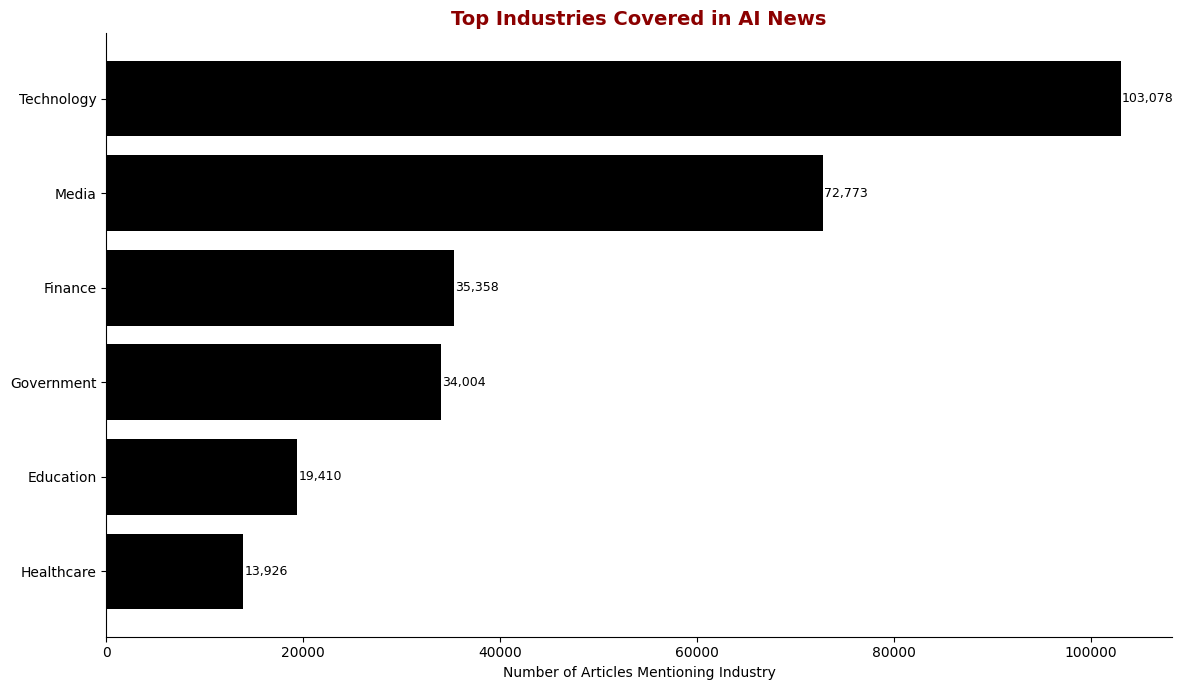

In [ ]:
# top industries
fig, ax = plt.subplots(figsize=(12, 7))
top_industries = industry_counts.head(6)

bars = ax.barh(
    top_industries['industry'],
    top_industries['article_count'],
    color='black'
)

for bar, val in zip(bars, top_industries['article_count']):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_title('Top Industries Covered in AI News', fontsize=14, fontweight='bold', color = '#8B0000')
ax.set_xlabel('Number of Articles Mentioning Industry')
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(path + 'figures/industry_coverage.png', dpi=300, bbox_inches='tight')
plt.show()

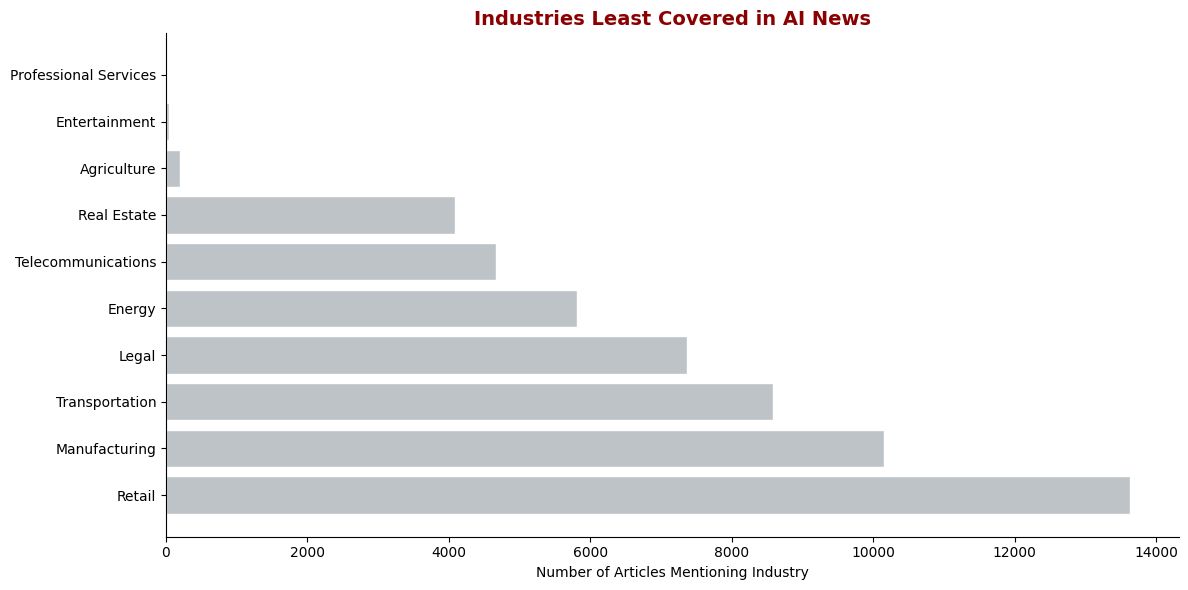

In [ ]:
# bottom industries
least_impacted = industry_counts.tail(10).sort_values('article_count')

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(
    least_impacted['industry'],
    least_impacted['article_count'],
    color='#bdc3c7',
    edgecolor='white'
)
ax.set_title('Industries Least Covered in AI News', fontsize=14, fontweight='bold',color = '#8B0000')
ax.set_xlabel('Number of Articles Mentioning Industry')
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(path + 'figures/industry_least_impacted.png', dpi=300, bbox_inches='tight')
plt.show()

### Companies

In [ ]:
top_companies = (
    df_entity[df_entity['industry'] != 'Unknown']
    .groupby(['industry', 'org'])['article_id']
    .nunique()
    .reset_index()
    .rename(columns={'article_id': 'article_count'})
)

# rank within industry
top_companies['rank'] = (
    top_companies
    .groupby('industry')['article_count']
    .rank(ascending=False, method='first')
)

top5_per_industry = (
    top_companies[top_companies['rank'] <= 3]
    .sort_values(['industry', 'rank'])
)

print("\nTop 5 companies per industry:")
print(top5_per_industry.to_string())

top5_per_industry.to_csv(path + 'top_companies_per_industry.csv', index=False)



Top 5 companies per industry:
                    industry                                                         org  article_count  rank
1                Agriculture                                             Farmerwiregrass            145   1.0
0                Agriculture                                      Agri-Directory Mkulima             26   2.0
2                Agriculture                                                  Montana Ag             26   3.0
659                Education                                          Nasdaq Ipo Academy            957   1.0
637                Education                                                         Mit            678   2.0
564                Education                                                       Learn            515   3.0
1194                  Energy                                                     Chevron           1389   1.0
1213                  Energy                                                    Crudeoil 

In [ ]:
# kaggle dataset with 7million company names to further clean NER orgs
import kagglehub
import os

#!pip install --upgrade kagglehub

kaggle_data_path = kagglehub.dataset_download("peopledatalabssf/free-7-million-company-dataset")

print(f"Project output path: {path}")
print(f"Kaggle dataset files are accessible at: {kaggle_data_path}")

Using Colab cache for faster access to the 'free-7-million-company-dataset' dataset.
Project output path: /content/drive/MyDrive/nlp_final_project/
Kaggle dataset files are accessible at: /kaggle/input/free-7-million-company-dataset


In [ ]:
companies_df = pd.read_csv(os.path.join(kaggle_data_path, 'companies_sorted.csv'))
print(f"Shape of companies_df: {companies_df.shape}")
companies_df.head()

Shape of companies_df: (7173426, 11)


,Unnamed: 0,name,domain,year founded,industry,size range,locality,country,linkedin url,current employee estimate,total employee estimate
0,5872184,ibm,ibm.com,1911.0,information technology and services,10001+,"new york, new york, united states",united states,linkedin.com/company/ibm,274047,716906
1,4425416,tata consultancy services,tcs.com,1968.0,information technology and services,10001+,"bombay, maharashtra, india",india,linkedin.com/company/tata-consultancy-services,190771,341369
2,21074,accenture,accenture.com,1989.0,information technology and services,10001+,"dublin, dublin, ireland",ireland,linkedin.com/company/accenture,190689,455768
3,2309813,us army,goarmy.com,1800.0,military,10001+,"alexandria, virginia, united states",united states,linkedin.com/company/us-army,162163,445958
4,1558607,ey,ey.com,1989.0,accounting,10001+,"london, greater london, united kingdom",united kingdom,linkedin.com/company/ernstandyoung,158363,428960


In [ ]:
lowercase_company_names = set(companies_df['name'].str.lower())

top_companies = (
    df_entity[
        (df_entity['industry'] != 'Unknown') &
        (df_entity['org'].str.lower().isin(lowercase_company_names))
    ]
    .groupby(['industry', 'org'])['article_id']
    .nunique()
    .reset_index()
    .rename(columns={'article_id': 'article_count'})
)

# rank within industry
top_companies['rank'] = (
    top_companies
    .groupby('industry')['article_count']
    .rank(ascending=False, method='first')
)
top5_per_industry = (
    top_companies[top_companies['rank'] <= 5]
    .sort_values(['industry', 'rank'])
)
print("\nTop 5 companies per industry:")
print(top5_per_industry.to_string())


Top 5 companies per industry:
                   industry                  org  article_count  rank
244               Education                  Mit            678   1.0
339               Education             Stanford            346   2.0
340               Education  Stanford University            318   3.0
181               Education                  Iit            233   4.0
261               Education                 Ncaa            206   5.0
473                  Energy              Chevron           1389   1.0
561                  Energy                  Sun            210   2.0
542                  Energy             Reliance             89   3.0
552                  Energy                  Sol             64   4.0
528                  Energy                  Oci             58   5.0
578           Entertainment                Poker             19   1.0
577           Entertainment                Kings             17   2.0
801                 Finance                  Esg           

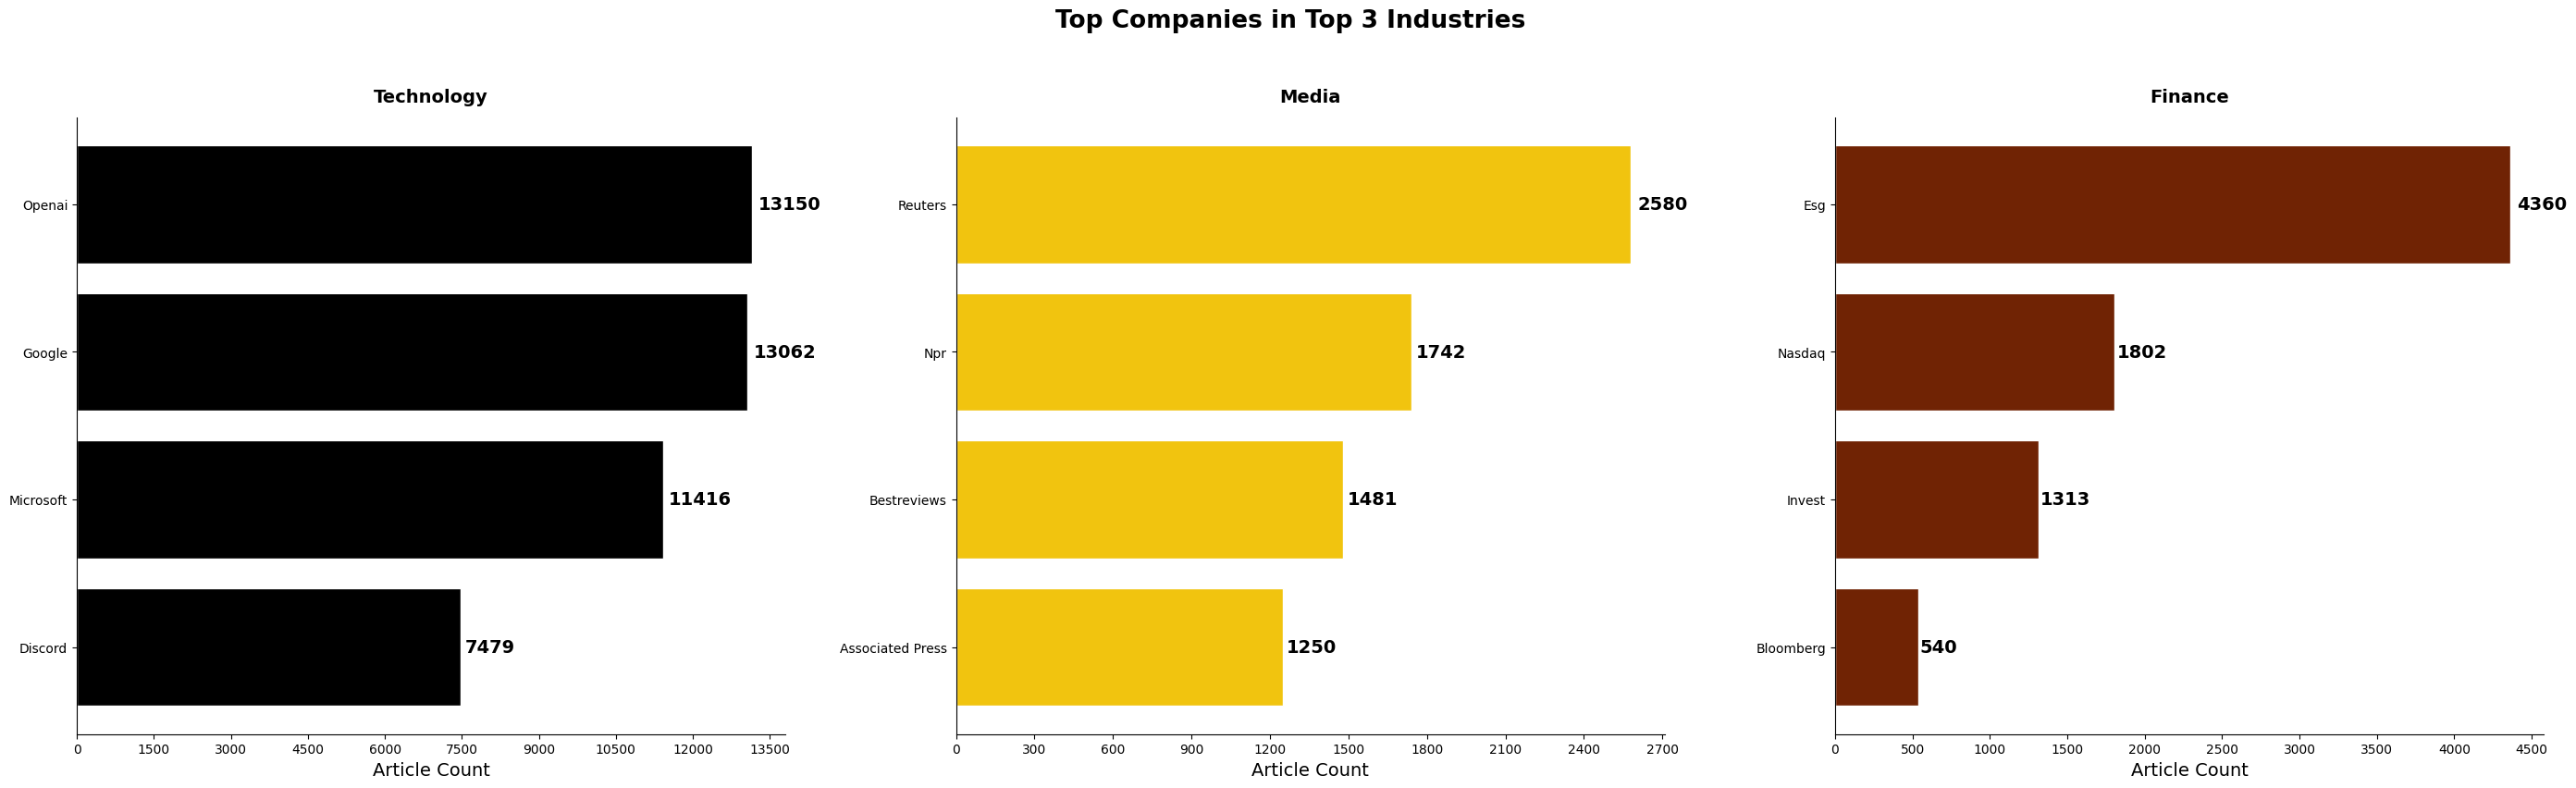

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import itertools

selected_industries = ['Technology', 'Media', 'Finance']

top_companies = (
    df_entity[
        (df_entity['industry'] != 'Unknown') &
        (df_entity['industry'].isin(selected_industries)) &
        (df_entity['org'].str.lower().isin(lowercase_company_names))
    ]
    .groupby(['industry', 'org'])['article_id']
    .nunique()
    .reset_index()
    .rename(columns={'article_id': 'article_count'})
)

top_companies['rank'] = (
    top_companies
    .groupby('industry')['article_count']
    .rank(ascending=False, method='first')
)

top3_per_industry = (
    top_companies[top_companies['rank'] <= 4]
    .sort_values(['industry', 'rank'])
)

fig, axes = plt.subplots(2, 3, figsize=(28, 15))

plot_colors = itertools.cycle([
    'black', COLORS['positive'], '#702304', '#8c8c8c', '#5e5e5e', '#a3a3a3',
    '#6b6b6b', '#cccccc', '#4a4a4a'
])

for ax, industry in zip(axes.flatten(), selected_industries):
    data = top3_per_industry[top3_per_industry['industry'] == industry]
    color = next(plot_colors)
    bars = ax.barh(data['org'], data['article_count'], color=color, edgecolor='white')

    for bar in bars:
        width = bar.get_width()
        ax.text(width * 1.01, bar.get_y() + bar.get_height() / 2,
                f'{int(width)}', va='center', ha='left', fontsize=14, fontweight='bold')

    ax.set_title(industry, fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('Article Count', fontsize=14)
    ax.invert_yaxis()
    ax.spines[['top', 'right']].set_visible(False)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))


for i in range(len(selected_industries), len(axes.flatten())):
    fig.delaxes(axes.flatten()[i])

fig.suptitle('Top Companies in Top 3 Industries', fontsize=19, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

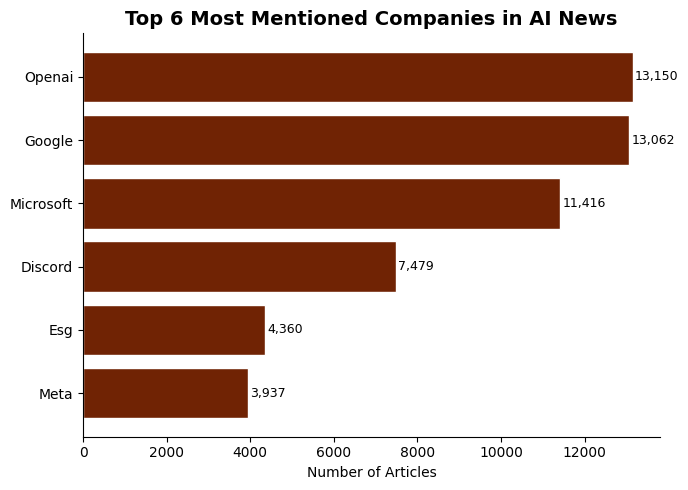

In [ ]:
top_companies_overall = (
    df_entity[(df_entity['industry'] != 'Unknown') &
        (df_entity['org'].str.lower().isin(lowercase_company_names))]
    .groupby('org')['article_id']
    .nunique()
    .reset_index()
    .rename(columns={'article_id': 'article_count'})
    .sort_values('article_count', ascending=False)
    .head(6)
)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.barh(
    top_companies_overall['org'],
    top_companies_overall['article_count'],
    color='#702304',
    edgecolor='white'
)

for bar, val in zip(bars, top_companies_overall['article_count']):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_title('Top 6 Most Mentioned Companies in AI News',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Articles')
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(path + 'figures/top_companies.png', dpi=600, bbox_inches='tight')
plt.show()

### SENTIMENT

In [ ]:
# sentiment calculator
def net_sentiment(group):
    total = len(group)
    if total == 0:
        return 0
    pos = (group['sentiment_label'] == 'positive').sum()
    neg = (group['sentiment_label'] == 'negative').sum()
    return (pos - neg) / total

In [ ]:
industry_df = df_entity[df_entity['industry'] != 'Unknown'].copy()

# sentiment distribution per industry
industry_sentiment = (
    industry_df.groupby('industry')
    .agg(
        total_articles=('article_id', 'nunique'),
        net_sentiment=('sentiment_label', lambda x: net_sentiment(
            pd.DataFrame({'sentiment_label': x})
        )),
        pct_positive=('sentiment_label', lambda x: (x == 'positive').mean()),
        pct_neutral=('sentiment_label', lambda x: (x == 'neutral').mean()),
        pct_negative=('sentiment_label', lambda x: (x == 'negative').mean())
    )
    .reset_index()
    .sort_values('net_sentiment', ascending=False)
)

print(industry_sentiment.to_string())

                 industry  total_articles  net_sentiment  pct_positive  pct_neutral  pct_negative
10  Professional Services              16       0.562500      0.562500     0.437500      0.000000
0             Agriculture             197       0.487310      0.517766     0.451777      0.030457
6              Healthcare           13926       0.441768      0.461679     0.518409      0.019911
3           Entertainment              36       0.416667      0.416667     0.583333      0.000000
11            Real Estate            4081       0.322093      0.348372     0.625349      0.026279
2                  Energy            5810       0.309535      0.366743     0.576049      0.057208
14     Telecommunications            4660       0.297022      0.329937     0.637147      0.032915
12                 Retail           13633       0.290852      0.329129     0.632594      0.038277
4                 Finance           35358       0.281023      0.346897     0.587229      0.065874
13             Techn

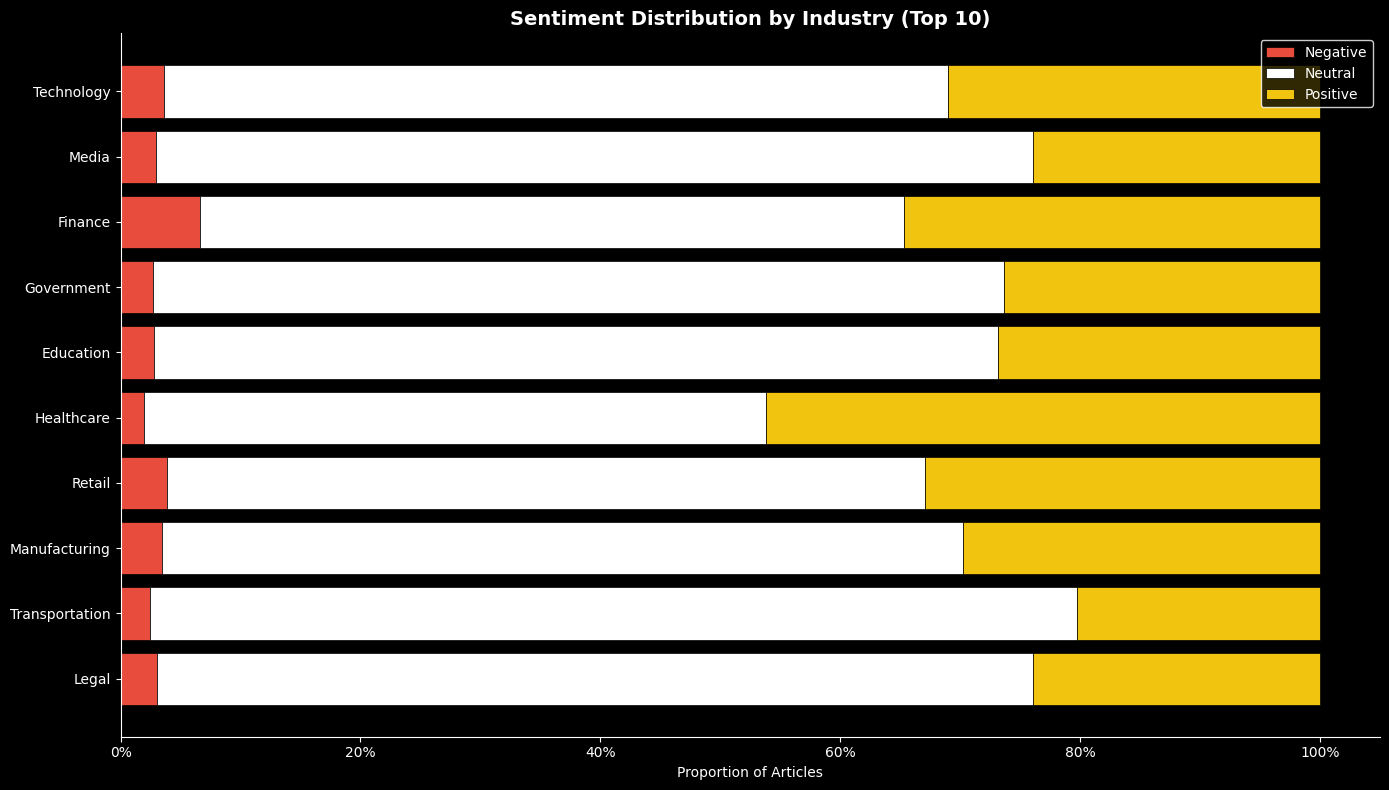

In [ ]:
# stacked bar
top15 = industry_sentiment.nlargest(10, 'total_articles')

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

ax.barh(top15['industry'], top15['pct_negative'],
        color=COLORS['negative'], label='Negative',
        edgecolor='black', linewidth=0.5)
ax.barh(top15['industry'], top15['pct_neutral'],
        left=top15['pct_negative'],
        color=COLORS['neutral'], label='Neutral',
        edgecolor='black', linewidth=0.5)
ax.barh(top15['industry'], top15['pct_positive'],
        left=top15['pct_negative'] + top15['pct_neutral'],
        color=COLORS['positive'], label='Positive',
        edgecolor='black', linewidth=0.5)

ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Sentiment Distribution by Industry (Top 10)',
             fontsize=14, fontweight='bold', color='white')
ax.set_xlabel('Proportion of Articles', color='white')
ax.invert_yaxis()
ax.tick_params(colors='white')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['bottom', 'left']].set_color('white')
for label in ax.get_yticklabels():
    label.set_color('white')
plt.legend(facecolor='black', labelcolor='white', edgecolor='white')
plt.tight_layout()
plt.savefig(path + 'figures/industry_sentiment_stacked.png',
            dpi=300, bbox_inches='tight', facecolor='black')
plt.show()

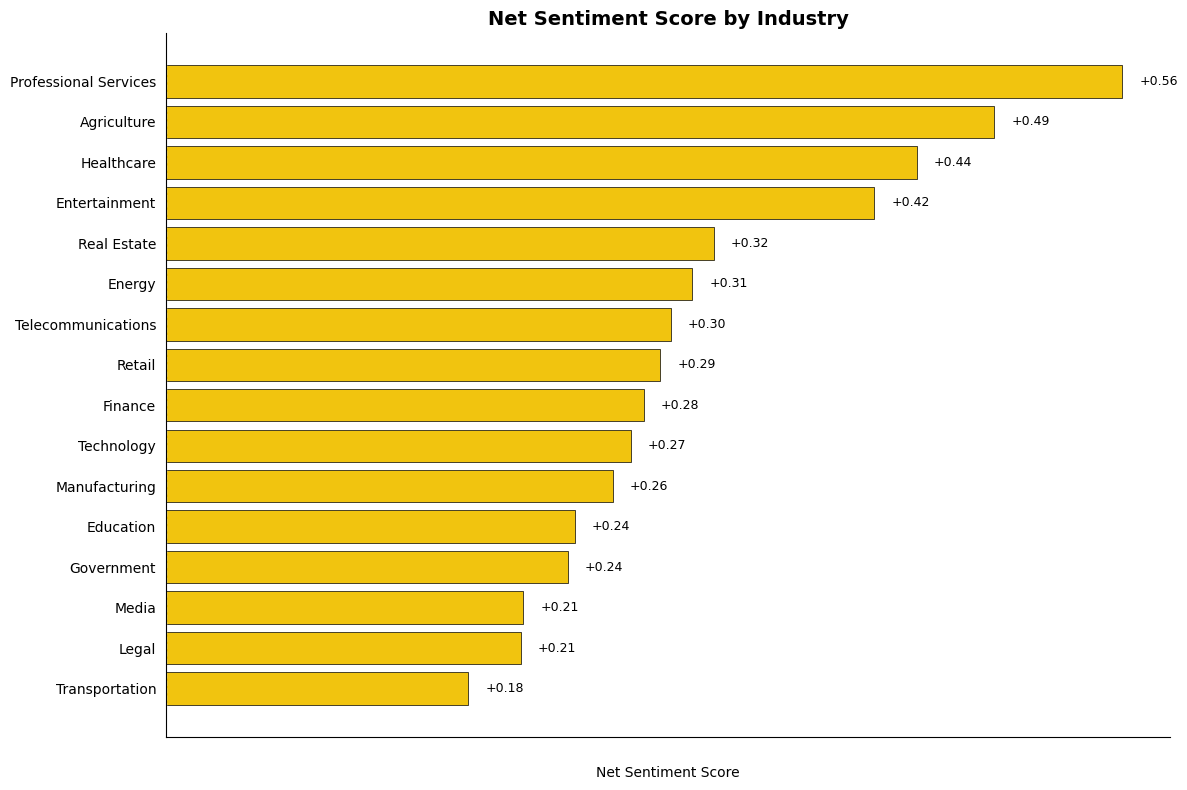

In [ ]:
# diverging bar
articles = industry_sentiment.nlargest(16, 'total_articles')
articles_sorted = articles.sort_values('net_sentiment')
bar_colors = [COLORS['positive'] if x >= 0 else COLORS['negative']
              for x in articles_sorted['net_sentiment']]

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bars = ax.barh(articles_sorted['industry'], articles_sorted['net_sentiment'],
               color=bar_colors, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, articles_sorted['net_sentiment']):
    ha = 'left' if val >= 0 else 'right'
    offset = 0.01 if val >= 0 else -0.01
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.2f}', va='center', ha=ha,
            fontsize=9, color='black')

ax.axvline(x=0, color='white', linewidth=1, linestyle='--')
ax.set_title('Net Sentiment Score by Industry',
             fontsize=14, fontweight='bold', color='black')
ax.set_xlabel('Net Sentiment Score', color='black')
ax.tick_params(colors='white')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['bottom', 'left']].set_color('black')
for label in ax.get_yticklabels():
    label.set_color('black')
plt.tight_layout()
plt.savefig(path + 'figures/industry_net_sentiment.png', bbox_inches='tight', facecolor='black')
plt.show()

/tmp/ipykernel_26723/242811193.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(net_sentiment)


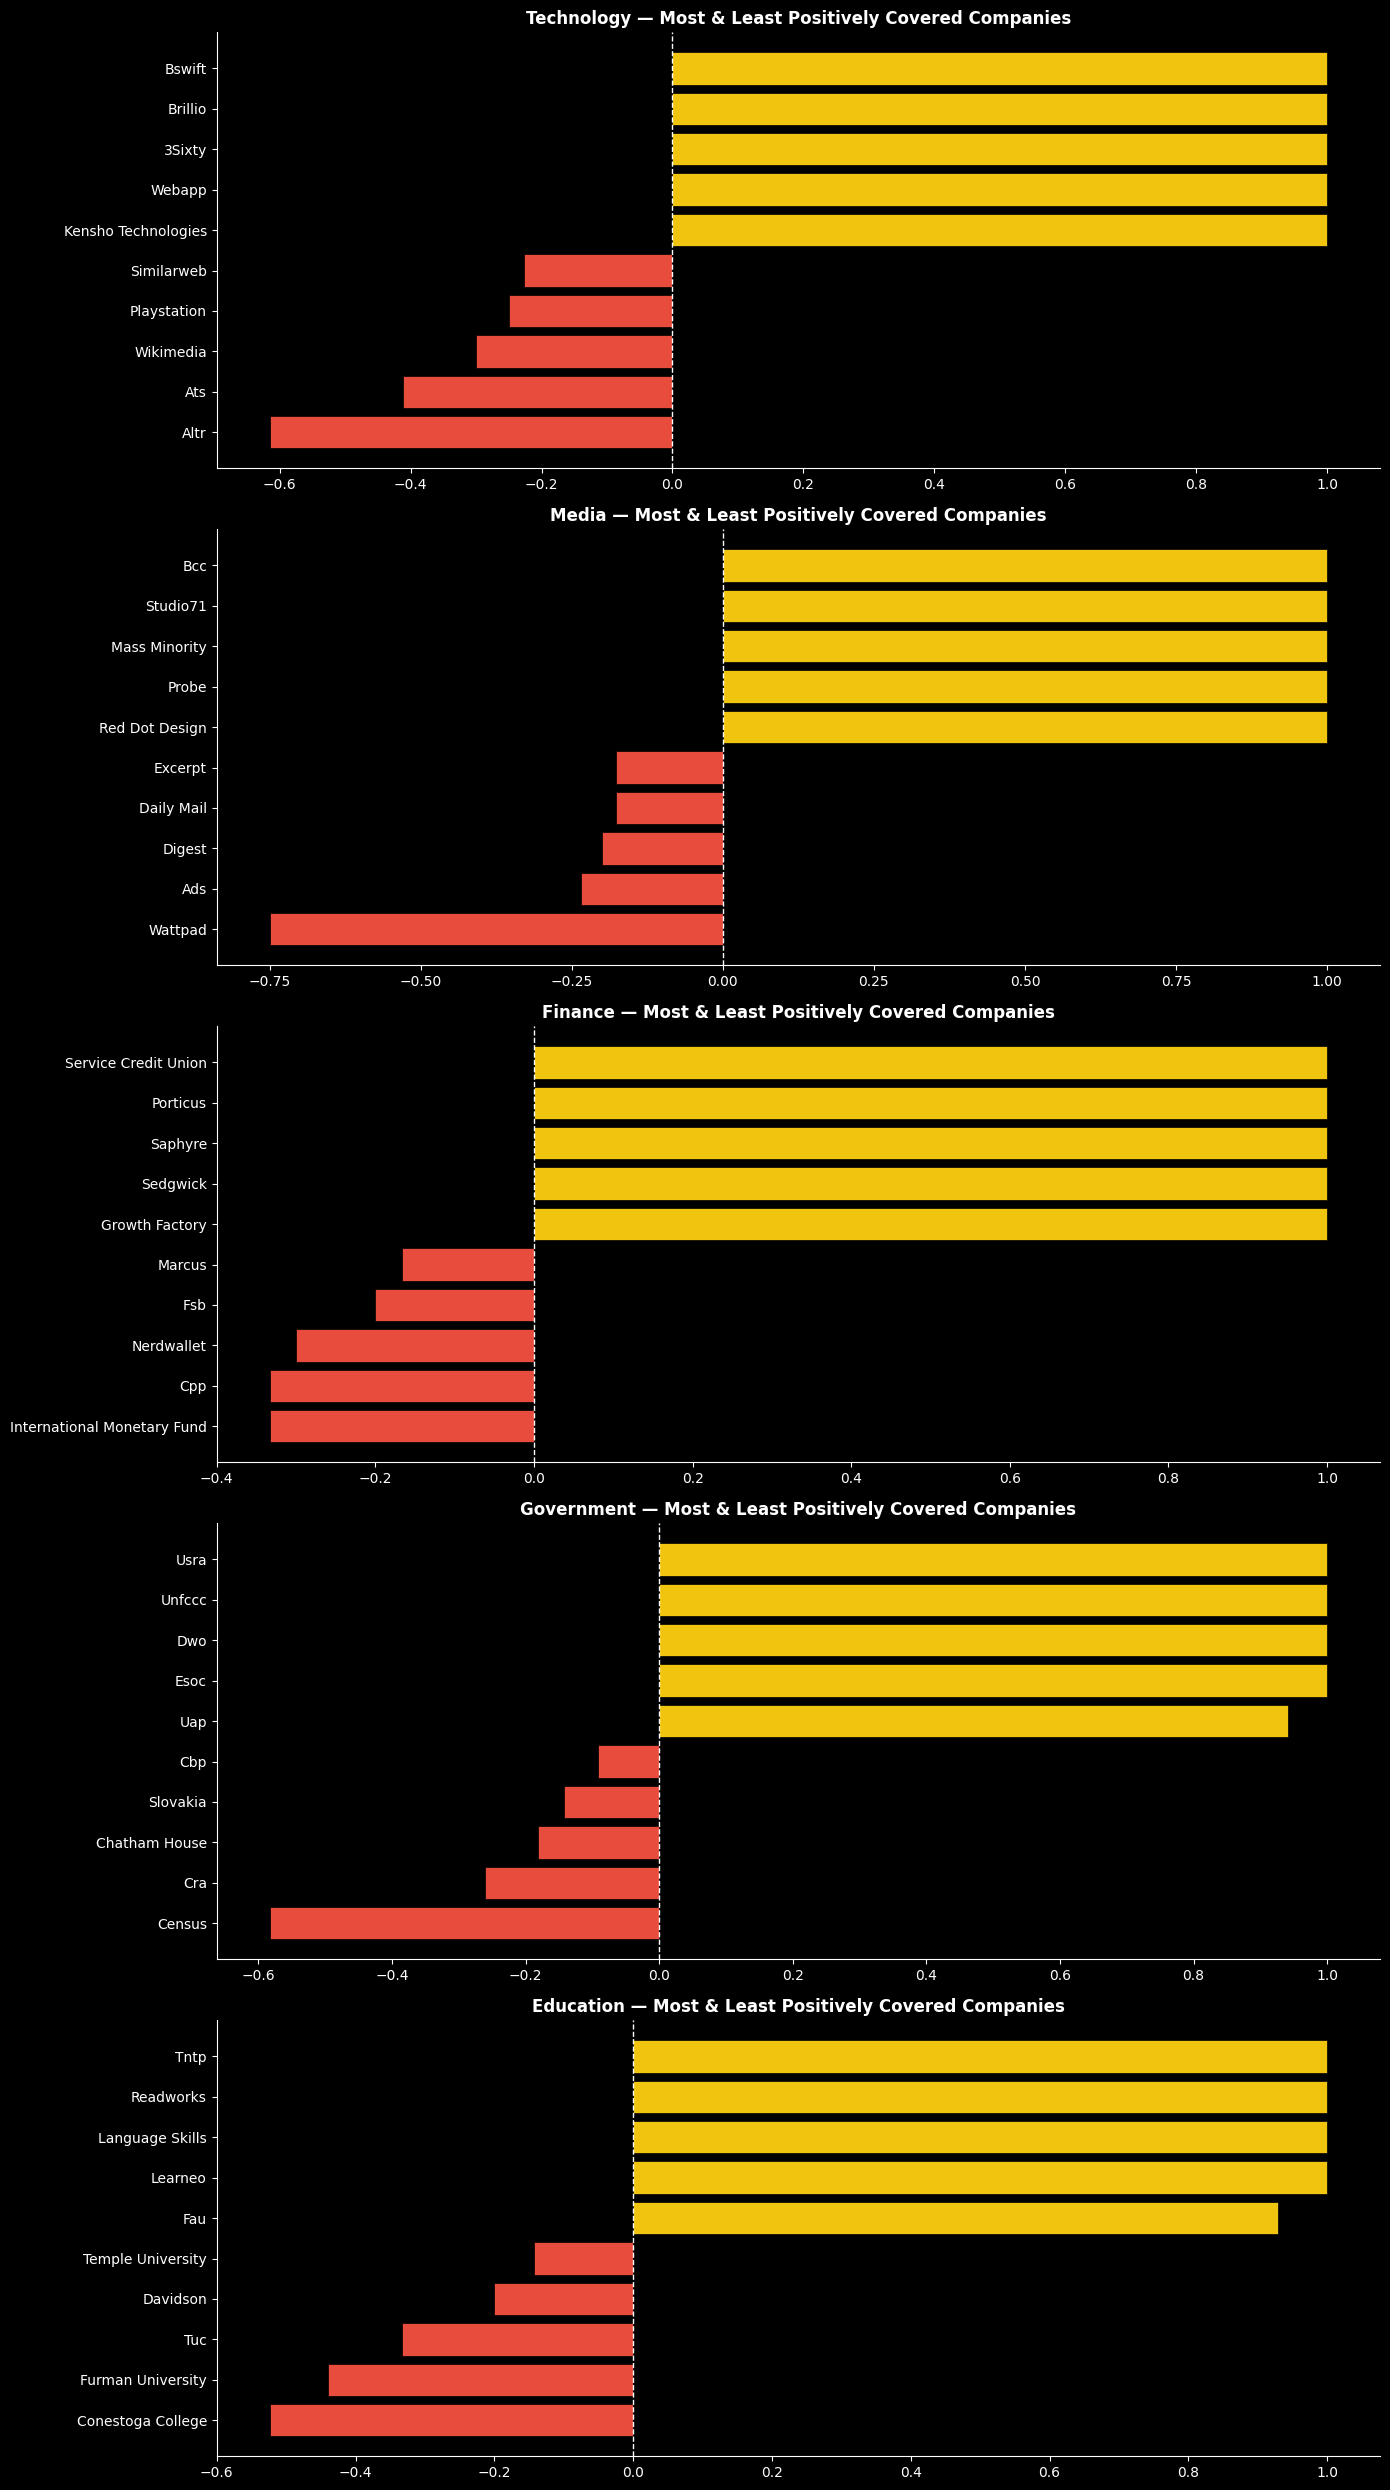

In [ ]:
# top and bottom industries
top5_industries = industry_sentiment.nlargest(5, 'total_articles')['industry'].tolist()

company_sentiment = (
    industry_df[
        (industry_df['industry'].isin(top5_industries)) &
        (industry_df['org'].str.lower().isin(lowercase_company_names))
    ]
    .groupby(['industry', 'org'])
    .filter(lambda x: x['article_id'].nunique() >= 10)
    .groupby(['industry', 'org'])
    .apply(net_sentiment)
    .reset_index()
    .rename(columns={0: 'net_sentiment'})
)

fig, axes = plt.subplots(len(top5_industries), 1,
                          figsize=(14, 5 * len(top5_industries)))
fig.patch.set_facecolor('black')

for ax, industry in zip(axes, top5_industries):
    ind_data = company_sentiment[
        company_sentiment['industry'] == industry
    ].sort_values('net_sentiment')

    top_pos = ind_data.nlargest(5, 'net_sentiment')
    top_neg = ind_data.nsmallest(5, 'net_sentiment')
    plot_data = pd.concat([top_neg, top_pos]).drop_duplicates()
    plot_data = plot_data.sort_values('net_sentiment')

    colors = [COLORS['positive'] if x >= 0 else COLORS['negative']
              for x in plot_data['net_sentiment']]

    ax.barh(plot_data['org'], plot_data['net_sentiment'],
            color=colors, edgecolor='black', linewidth=0.5)
    ax.axvline(x=0, color='white', linewidth=1, linestyle='--')
    ax.set_title(f'{industry} — Most & Least Positively Covered Companies',
                 fontsize=12, fontweight='bold', color='white')
    ax.set_facecolor('black')
    ax.tick_params(colors='white')
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['bottom', 'left']].set_color('white')
    for label in ax.get_yticklabels():
        label.set_color('white')

plt.tight_layout()
plt.savefig(path + 'figures/company_sentiment_by_industry.png',
            dpi=300, bbox_inches='tight', facecolor='black')
plt.show()

### By What Means Industries are Being Affected

In [ ]:
# filter noise topics
topic_clean = df_articles[~df_articles['is_noise_topic']].copy()

topic_sentiment = (
    topic_clean.groupby('topic_label')
    .apply(net_sentiment)
    .reset_index()
    .rename(columns={0: 'net_sentiment'})
)

topic_stats = (
    topic_clean.groupby('topic_label')
    .agg(
        total_articles=('article_id', 'nunique'),
        pct_positive=('sentiment_label', lambda x: (x == 'positive').mean()),
        pct_neutral=('sentiment_label', lambda x: (x == 'neutral').mean()),
        pct_negative=('sentiment_label', lambda x: (x == 'negative').mean())
    )
    .reset_index()
)

topic_sentiment = topic_sentiment.merge(topic_stats, on='topic_label')
topic_sentiment = topic_sentiment.sort_values('net_sentiment', ascending=False)

print(topic_sentiment[['topic_label', 'net_sentiment',
                        'total_articles']].to_string())

                                       topic_label  net_sentiment  total_articles
25                  Global AI Industry News Trends       0.458333             864
0           AI Advancements in Healthcare Research       0.412574            4072
10        AI Integration in Automotive Engineering       0.411405             982
6                  AI Hardware and Chip Innovation       0.370575            3446
13              AI for Satellite Earth Observation       0.367179             975
9             AI Infrastructure Energy Consumption       0.339161             572
12                  AI Technology and Media Trends       0.335523           46736
29                                           Noise       0.292823            2090
22    Enterprise AI Data Infrastructure Management       0.262023             603
3                 AI Features in Smartphone Series       0.254724            1323
26                Global AI Market Trends Analysis       0.251279           32458
27             G

/tmp/ipykernel_26723/60316714.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(net_sentiment)


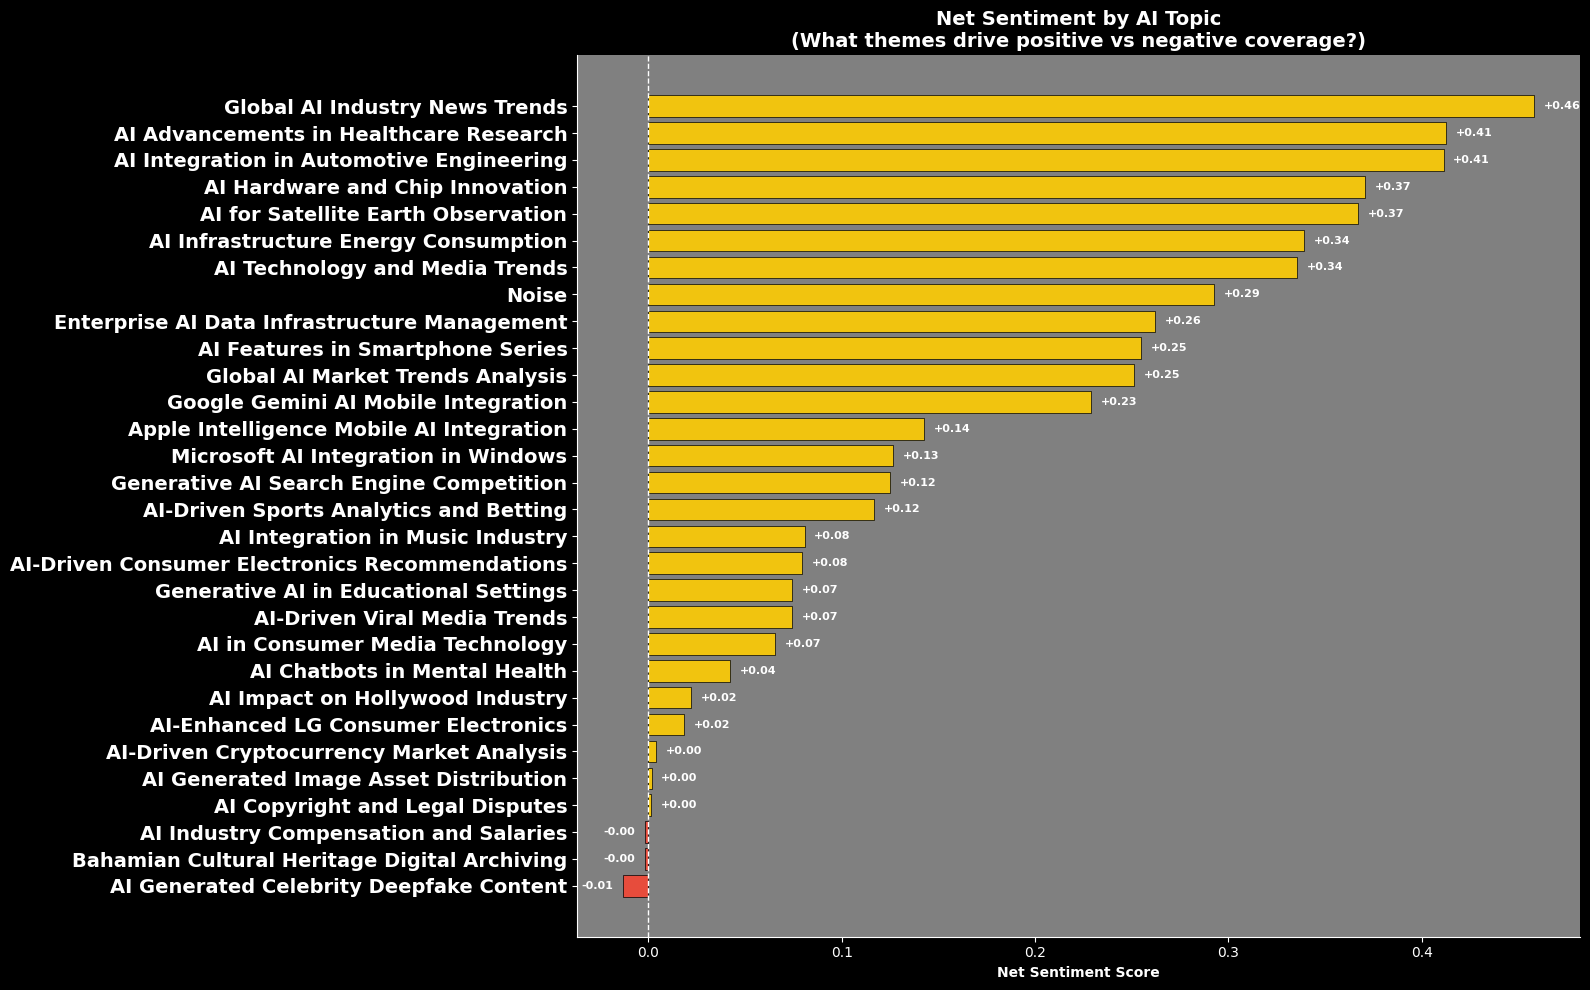

In [ ]:
topic_sorted = topic_sentiment.sort_values('net_sentiment')
bar_colors = [COLORS['positive'] if x >= 0 else COLORS['negative']
              for x in topic_sorted['net_sentiment']]

fig, ax = plt.subplots(figsize=(16, 10))
fig.patch.set_facecolor('black')
ax.set_facecolor('gray')

bars = ax.barh(
    topic_sorted['topic_label'],
    topic_sorted['net_sentiment'],
    color=bar_colors,
    edgecolor='black',
    linewidth=0.5
)

for bar, val in zip(bars, topic_sorted['net_sentiment']):
    ha = 'left' if val >= 0 else 'right'
    offset = 0.005 if val >= 0 else -0.005
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.2f}', va='center', ha=ha,
            fontsize=8, color='white', fontweight='bold')

ax.axvline(x=0, color='white', linewidth=1, linestyle='--')
ax.set_title('Net Sentiment by AI Topic\n(What themes drive positive vs negative coverage?)',
             fontsize=14, fontweight='bold', color='white')
ax.set_xlabel('Net Sentiment Score', color='white', fontweight='bold')
ax.tick_params(colors='white')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['bottom', 'left']].set_color('white')
for label in ax.get_yticklabels():
    label.set_color('white'),
    label.set_fontweight('bold'),
    label.set_fontsize(14)
plt.tight_layout()
plt.savefig(path + 'figures/topic_net_sentiment.png',
            dpi=600, bbox_inches='tight', facecolor='black')
plt.show()

In [ ]:
df_entity.head()

,article_id,org,industry,sentiment_label,sentiment_score,prob_negative,prob_neutral,prob_positive,topic_id,topic_label,is_noise_topic,date,year_month
0,1,Wonderful Products (Contact Support,Manufacturing,neutral,0.946678,0.003127,0.946678,0.050195,1,Global AI Market Trends Analysis,False,2024-07-01,2024-07
1,1,Werners Ai Art,Unknown,neutral,0.946678,0.003127,0.946678,0.050195,1,Global AI Market Trends Analysis,False,2024-07-01,2024-07
2,1,Instagram,Technology,neutral,0.946678,0.003127,0.946678,0.050195,1,Global AI Market Trends Analysis,False,2024-07-01,2024-07
3,1,Luma Dream Machine,Unknown,neutral,0.946678,0.003127,0.946678,0.050195,1,Global AI Market Trends Analysis,False,2024-07-01,2024-07
4,1,Yanartas,Unknown,neutral,0.946678,0.003127,0.946678,0.050195,1,Global AI Market Trends Analysis,False,2024-07-01,2024-07


In [ ]:
df_articles.head()

,article_id,title,date,year_month,topic_id,topic_label,is_noise_topic,sentiment_label,sentiment_score,prob_negative,prob_neutral,prob_positive
0,0,"Bad Idea AI Price (BAD), Market Cap, Price Tod...",2025-06-23,2025-06,-1,Noise,True,neutral,0.856780,0.005402,0.856780,0.137819
1,1,This AI video of gymnastics might be the freak...,2024-07-01,2024-07,1,Global AI Market Trends Analysis,False,neutral,0.946678,0.003127,0.946678,0.050195
2,2,"If using AI feels like a chore, try this - Boi...",2024-09-22,2024-09,-1,Noise,True,neutral,0.994222,0.001734,0.994222,0.004044
3,3,The Road Ahead: How China's AI Foundation Mode...,2023-11-10,2023-11,-1,Noise,True,positive,0.904910,0.004511,0.090579,0.904910
4,4,Microsoft and Nvidia to Empower Developers wit...,2023-11-19,2023-11,-1,Noise,True,positive,0.845634,0.003802,0.150564,0.845634


/tmp/ipykernel_26723/3028171577.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(net_sentiment)


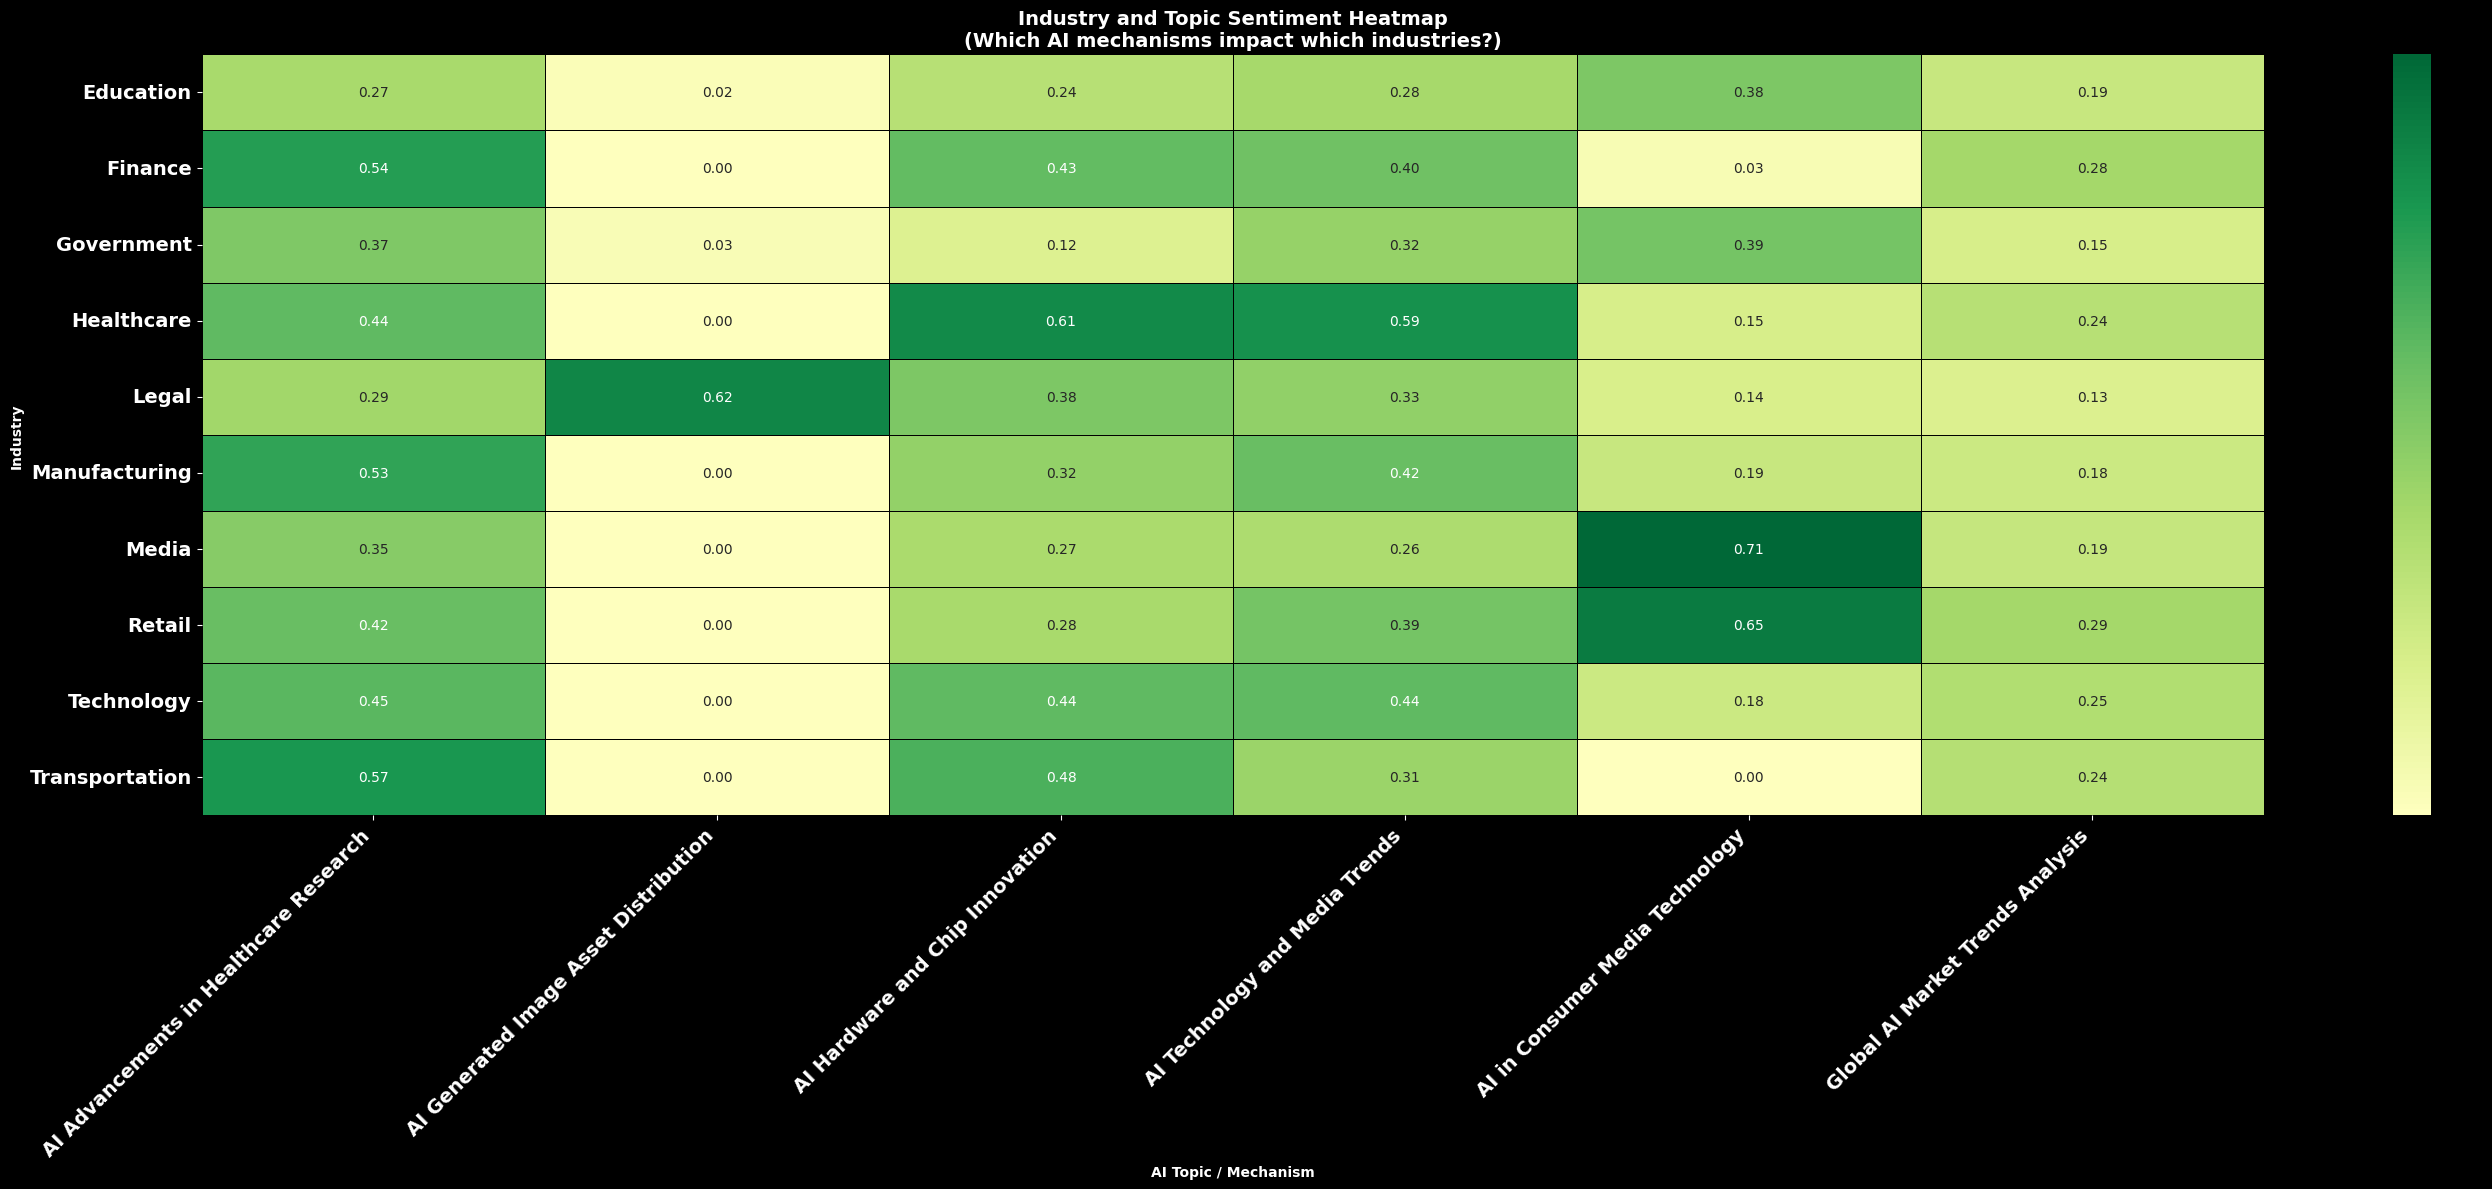

In [ ]:
industry_topic = (
    df_entity[df_entity['industry'] != 'Unknown']
    .query('is_noise_topic == False')
)

heatmap_data = (
    industry_topic.groupby(['industry', 'topic_label'])
    .apply(net_sentiment)
    .reset_index()
    .rename(columns={0: 'net_sentiment'})
)

top10_industries = industry_sentiment.nlargest(10, 'total_articles')['industry'].tolist()
top15_topics = topic_sentiment.nlargest(6, 'total_articles')['topic_label'].tolist()

heatmap_pivot = (
    heatmap_data[
        heatmap_data['industry'].isin(top10_industries) &
        heatmap_data['topic_label'].isin(top15_topics)
    ]
    .pivot_table(
        index='industry',
        columns='topic_label',
        values='net_sentiment',
        fill_value=0
    )
)

fig, ax = plt.subplots(figsize=(28, 12))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

sns.heatmap(
    heatmap_pivot,
    cmap='RdYlGn',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    linecolor='black',
    ax=ax,
    cbar_kws={'label': 'Net Sentiment Score'}
)

ax.set_title('Industry and Topic Sentiment Heatmap\n(Which AI mechanisms impact which industries?)',
             fontsize=14, fontweight='bold', color='white')
ax.set_xlabel('AI Topic / Mechanism', color='white', fontweight='bold')
ax.set_ylabel('Industry', color='white', fontweight='bold')
ax.tick_params(colors='white', axis='both')
plt.xticks(rotation=45, ha='right', color='white', fontsize=14, fontweight='bold')
plt.yticks(color='white',rotation = 0, ha= 'right',fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(path + 'figures/industry_topic_heatmap.png',
            dpi=600, bbox_inches='tight', facecolor='black')
plt.show()

In [ ]:
# topics in each industry

industry_topic_counts = (
    industry_topic.groupby(['industry', 'topic_label'])['article_id']
    .nunique()
    .reset_index()
    .rename(columns={'article_id': 'article_count'})
)

# top 3 per industry
industry_topic_counts['rank'] = (
    industry_topic_counts
    .groupby('industry')['article_count']
    .rank(ascending=False, method='first')
)

top3_topics_per_industry = (
    industry_topic_counts[
        (industry_topic_counts['rank'] <= 3) &
        (industry_topic_counts['industry'].isin(top10_industries))
    ]
    .sort_values(['industry', 'rank'])
)

print("\nTop 3 AI topics per industry:")
print(top3_topics_per_industry.to_string())


Top 3 AI topics per industry:
           industry                               topic_label  article_count  rank
16        Education            AI Technology and Media Trends           5890   1.0
29        Education          Global AI Market Trends Analysis           2342   2.0
32        Education                                     Noise            957   3.0
79          Finance            AI Technology and Media Trends           8294   1.0
93          Finance          Global AI Market Trends Analysis           5845   2.0
81          Finance           AI in Consumer Media Technology           3758   3.0
109      Government            AI Technology and Media Trends          11312   1.0
123      Government          Global AI Market Trends Analysis           6203   2.0
97       Government    AI Advancements in Healthcare Research            600   3.0
139      Healthcare            AI Technology and Media Trends           5019   1.0
127      Healthcare    AI Advancements in Healthcare Res

### AI Adaption (Success or Failure)

In [ ]:
adoption_keywords = [
    'adopt', 'implement', 'deploy', 'integrat', 'transform',
    'challeng', 'barrier', 'resist', 'fail', 'success',
    'regulat', 'ethic', 'workforce', 'upskill', 'invest',
    'roi', 'productiv', 'cost', 'risk', 'strateg'
]

def is_adoption_topic(label):
    label_lower = str(label).lower()
    return any(kw in label_lower for kw in adoption_keywords)

topic_clean['is_adoption'] = topic_clean['topic_label'].apply(is_adoption_topic)

adoption_df = topic_clean[topic_clean['is_adoption']].copy()

print(f"Adoption-related articles: {len(adoption_df):,}")
print(f"Adoption topics identified:")
print(adoption_df['topic_label'].value_counts().to_string())

print("\nAll topic labels for review:")
print(topic_clean['topic_label'].unique())

Adoption-related articles: 5,427
Adoption topics identified:
topic_label
AI Integration in Music Industry            1387
Apple Intelligence Mobile AI Integration    1243
Microsoft AI Integration in Windows         1160
AI Integration in Automotive Engineering     982
Google Gemini AI Mobile Integration          655

All topic labels for review:
['Global AI Market Trends Analysis' 'Google Gemini AI Mobile Integration'
 'Noise' 'AI Technology and Media Trends'
 'AI Generated Image Asset Distribution'
 'AI Infrastructure Energy Consumption'
 'AI Advancements in Healthcare Research'
 'AI-Driven Sports Analytics and Betting'
 'AI Impact on Hollywood Industry' 'AI-Driven Viral Media Trends'
 'AI Hardware and Chip Innovation'
 'AI Generated Celebrity Deepfake Content'
 'Generative AI Search Engine Competition'
 'AI-Enhanced LG Consumer Electronics'
 'AI-Driven Cryptocurrency Market Analysis'
 'AI in Consumer Media Technology'
 'Enterprise AI Data Infrastructure Management'
 'AI-Driven Consum

/tmp/ipykernel_26723/2858953463.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(net_sentiment)


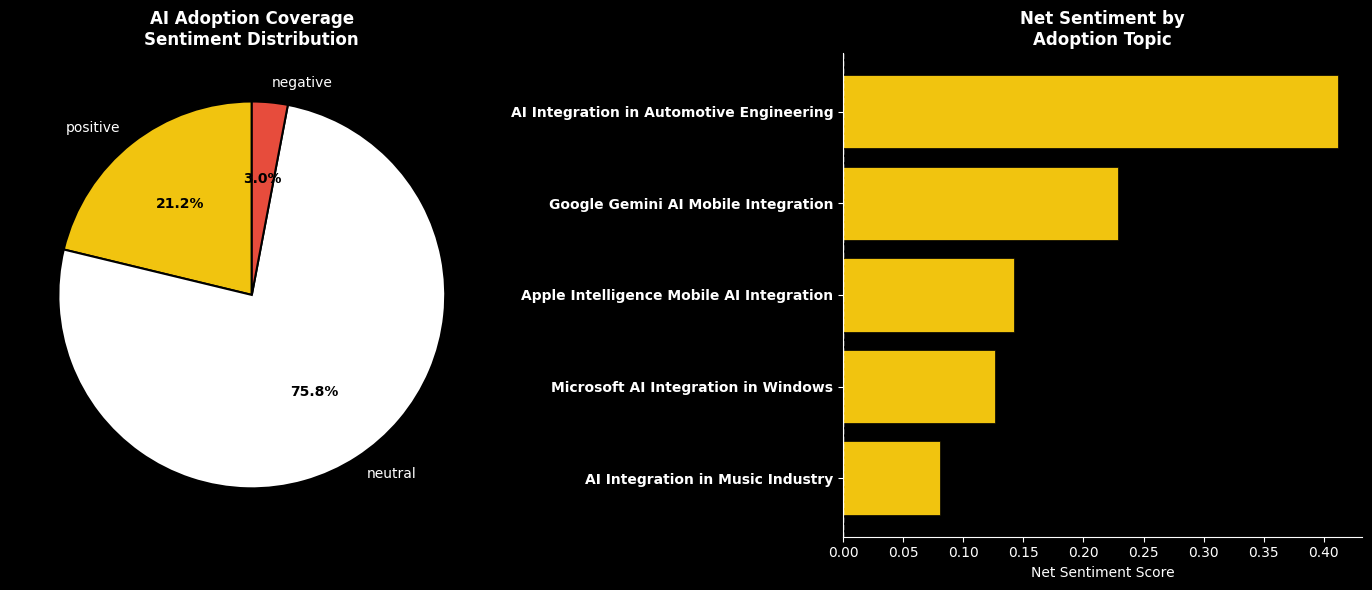

In [ ]:
adoption_sentiment_counts = (
    adoption_df['sentiment_label']
    .value_counts()
    .reindex(['positive', 'neutral', 'negative'])
    .fillna(0)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('black')

# pie chart
wedge_colors = [COLORS['positive'], COLORS['neutral'], COLORS['negative']]
wedges, texts, autotexts = axes[0].pie(
    adoption_sentiment_counts,
    labels=adoption_sentiment_counts.index,
    colors=wedge_colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5}
)
for text in texts:
    text.set_color('white')
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
axes[0].set_title('AI Adoption Coverage\nSentiment Distribution',
                  fontsize=12, fontweight='bold', color='white')
axes[0].set_facecolor('black')

# bar chart adoption topics
adoption_topic_sentiment = (
    adoption_df.groupby('topic_label')
    .apply(net_sentiment)
    .reset_index()
    .rename(columns={0: 'net_sentiment'})
    .sort_values('net_sentiment')
)

bar_colors = [COLORS['positive'] if x >= 0 else COLORS['negative']
              for x in adoption_topic_sentiment['net_sentiment']]

axes[1].barh(
    adoption_topic_sentiment['topic_label'],
    adoption_topic_sentiment['net_sentiment'],
    color=bar_colors,
    edgecolor='black',
    linewidth=0.5
)
axes[1].axvline(x=0, color='white', linewidth=1, linestyle='--')
axes[1].set_title('Net Sentiment by\nAdoption Topic',
                  fontsize=12, fontweight='bold', color='white')
axes[1].set_xlabel('Net Sentiment Score', color='white')
axes[1].set_facecolor('black')
axes[1].tick_params(colors='white')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].spines[['bottom', 'left']].set_color('white')
for label in axes[1].get_yticklabels():
    label.set_color('white'),
    label.set_fontweight('bold')

plt.tight_layout()
plt.savefig(path + 'figures/adoption_overview.png',
            dpi=600, bbox_inches='tight', facecolor='black')
plt.show()

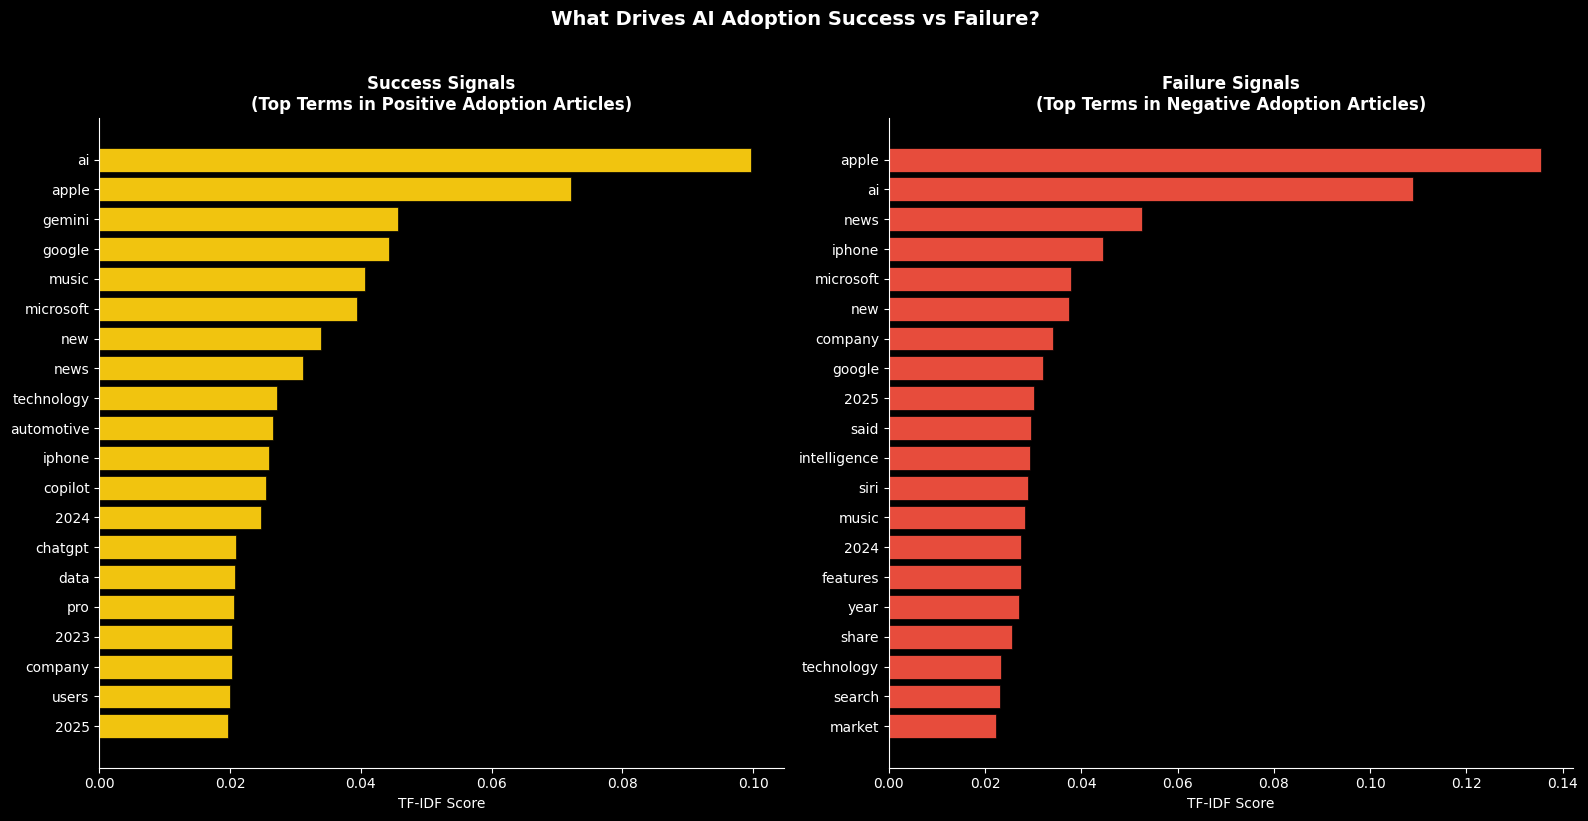

In [ ]:
# Success vs failure
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.patches as mpatches

# split
success_texts = adoption_df[
    adoption_df['sentiment_label'] == 'positive'
]['text_clean'] if 'text_clean' in adoption_df.columns else (
    adoption_df[adoption_df['sentiment_label'] == 'positive']
    .merge(df_base[['article_id', 'text_clean']], on='article_id')['text_clean']
)

failure_texts = adoption_df[
    adoption_df['sentiment_label'] == 'negative'
]['text_clean'] if 'text_clean' in adoption_df.columns else (
    adoption_df[adoption_df['sentiment_label'] == 'negative']
    .merge(df_base[['article_id', 'text_clean']], on='article_id')['text_clean']
)

def get_top_tfidf_terms(texts, n=20):
    """extract top n tfidf terms from a collection of texts"""
    vectorizer = TfidfVectorizer(
        max_features=5000,
        stop_words='english',
        ngram_range=(1, 2),
        min_df=3
    )
    tfidf_matrix = vectorizer.fit_transform(texts)
    mean_tfidf = tfidf_matrix.mean(axis=0).A1
    terms = vectorizer.get_feature_names_out()
    top_idx = mean_tfidf.argsort()[-n:][::-1]
    return pd.DataFrame({
        'term': terms[top_idx],
        'score': mean_tfidf[top_idx]
    })

success_terms = get_top_tfidf_terms(success_texts)
failure_terms = get_top_tfidf_terms(failure_texts)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor('black')

# success
axes[0].barh(
    success_terms['term'],
    success_terms['score'],
    color=COLORS['positive'],
    edgecolor='black',
    linewidth=0.5
)
axes[0].invert_yaxis()
axes[0].set_title('Success Signals\n(Top Terms in Positive Adoption Articles)',
                  fontsize=12, fontweight='bold', color='white')
axes[0].set_xlabel('TF-IDF Score', color='white')
axes[0].set_facecolor('black')
axes[0].tick_params(colors='white')
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].spines[['bottom', 'left']].set_color('white')
for label in axes[0].get_yticklabels():
    label.set_color('white')

# failure
axes[1].barh(
    failure_terms['term'],
    failure_terms['score'],
    color=COLORS['negative'],
    edgecolor='black',
    linewidth=0.5
)
axes[1].invert_yaxis()
axes[1].set_title('Failure Signals\n(Top Terms in Negative Adoption Articles)',
                  fontsize=12, fontweight='bold', color='white')
axes[1].set_xlabel('TF-IDF Score', color='white')
axes[1].set_facecolor('black')
axes[1].tick_params(colors='white')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].spines[['bottom', 'left']].set_color('white')
for label in axes[1].get_yticklabels():
    label.set_color('white')

plt.suptitle('What Drives AI Adoption Success vs Failure?',
             fontsize=14, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig(path + 'figures/adoption_keywords.png',
            dpi=300, bbox_inches='tight', facecolor='black')
plt.show()


/tmp/ipykernel_26723/3802012908.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(net_sentiment)


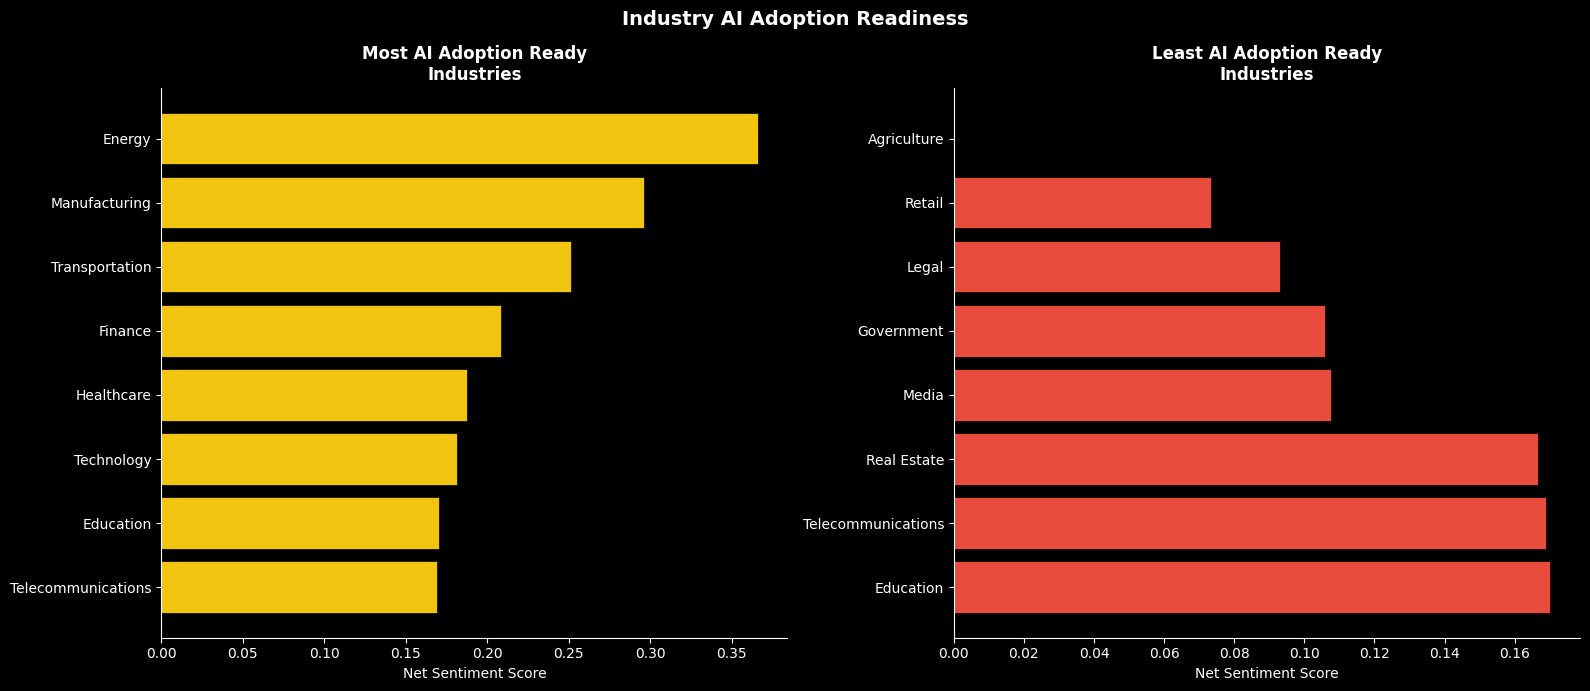

In [ ]:
# adaption by industry
adoption_by_industry = (
    adoption_df
    .merge(df_entity[['article_id', 'industry']].drop_duplicates(),
           on='article_id', how='left')
    .query('industry != "Unknown"')
    .groupby('industry')
    .apply(net_sentiment)
    .reset_index()
    .rename(columns={0: 'net_sentiment'})
    .sort_values('net_sentiment', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('black')

# most ready
top_ready = adoption_by_industry.head(8)
axes[0].barh(
    top_ready['industry'],
    top_ready['net_sentiment'],
    color=COLORS['positive'],
    edgecolor='black',
    linewidth=0.5
)
axes[0].invert_yaxis()
axes[0].set_title('Most AI Adoption Ready\nIndustries',
                  fontsize=12, fontweight='bold', color='white')
axes[0].set_xlabel('Net Sentiment Score', color='white')
axes[0].set_facecolor('black')
axes[0].tick_params(colors='white')
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].spines[['bottom', 'left']].set_color('white')
for label in axes[0].get_yticklabels():
    label.set_color('white')

# least ready
bottom_ready = adoption_by_industry.tail(8).sort_values('net_sentiment')
axes[1].barh(
    bottom_ready['industry'],
    bottom_ready['net_sentiment'],
    color=COLORS['negative'],
    edgecolor='black',
    linewidth=0.5
)
axes[1].invert_yaxis()
axes[1].set_title('Least AI Adoption Ready\nIndustries',
                  fontsize=12, fontweight='bold', color='white')
axes[1].set_xlabel('Net Sentiment Score', color='white')
axes[1].set_facecolor('black')
axes[1].tick_params(colors='white')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].spines[['bottom', 'left']].set_color('white')
for label in axes[1].get_yticklabels():
    label.set_color('white')

plt.suptitle('Industry AI Adoption Readiness',
             fontsize=14, fontweight='bold', color='white')
plt.tight_layout()
plt.savefig(path + 'figures/adoption_by_industry.png',
            dpi=300, bbox_inches='tight', facecolor='black')
plt.show()

/tmp/ipykernel_26723/225351752.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(net_sentiment)


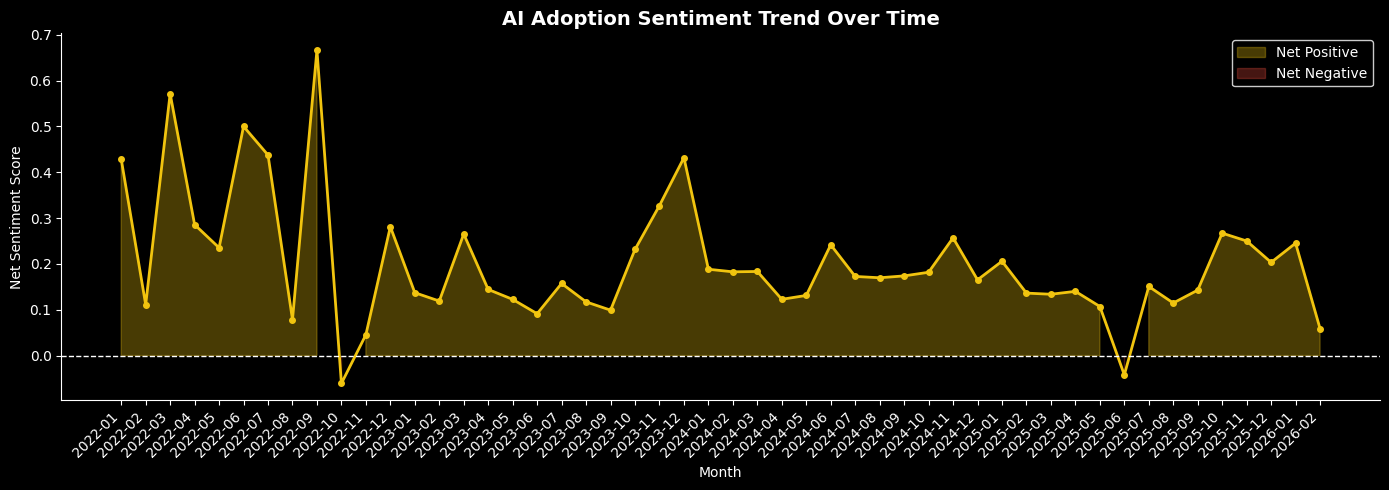

In [ ]:
# adaption over time
adoption_time = (
    adoption_df.groupby('year_month')
    .apply(net_sentiment)
    .reset_index()
    .rename(columns={0: 'net_sentiment'})
)

adoption_time['year_month'] = adoption_time['year_month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

ax.plot(
    adoption_time['year_month'],
    adoption_time['net_sentiment'],
    color=COLORS['positive'],
    linewidth=2,
    marker='o',
    markersize=4
)

ax.fill_between(
    adoption_time['year_month'],
    adoption_time['net_sentiment'],
    0,
    where=adoption_time['net_sentiment'] >= 0,
    color=COLORS['positive'],
    alpha=0.3,
    label='Net Positive'
)
ax.fill_between(
    adoption_time['year_month'],
    adoption_time['net_sentiment'],
    0,
    where=adoption_time['net_sentiment'] < 0,
    color=COLORS['negative'],
    alpha=0.3,
    label='Net Negative'
)

ax.axhline(y=0, color='white', linewidth=1, linestyle='--')
ax.set_title('AI Adoption Sentiment Trend Over Time',
             fontsize=14, fontweight='bold', color='white')
ax.set_xlabel('Month', color='white')
ax.set_ylabel('Net Sentiment Score', color='white')
ax.tick_params(colors='white')
plt.xticks(rotation=45, ha='right')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['bottom', 'left']].set_color('white')
plt.legend(facecolor='black', labelcolor='white', edgecolor='white')
plt.tight_layout()
plt.savefig(path + 'figures/adoption_trend.png',
            dpi=300, bbox_inches='tight', facecolor='black')
plt.show()

### Sentiment Over Time

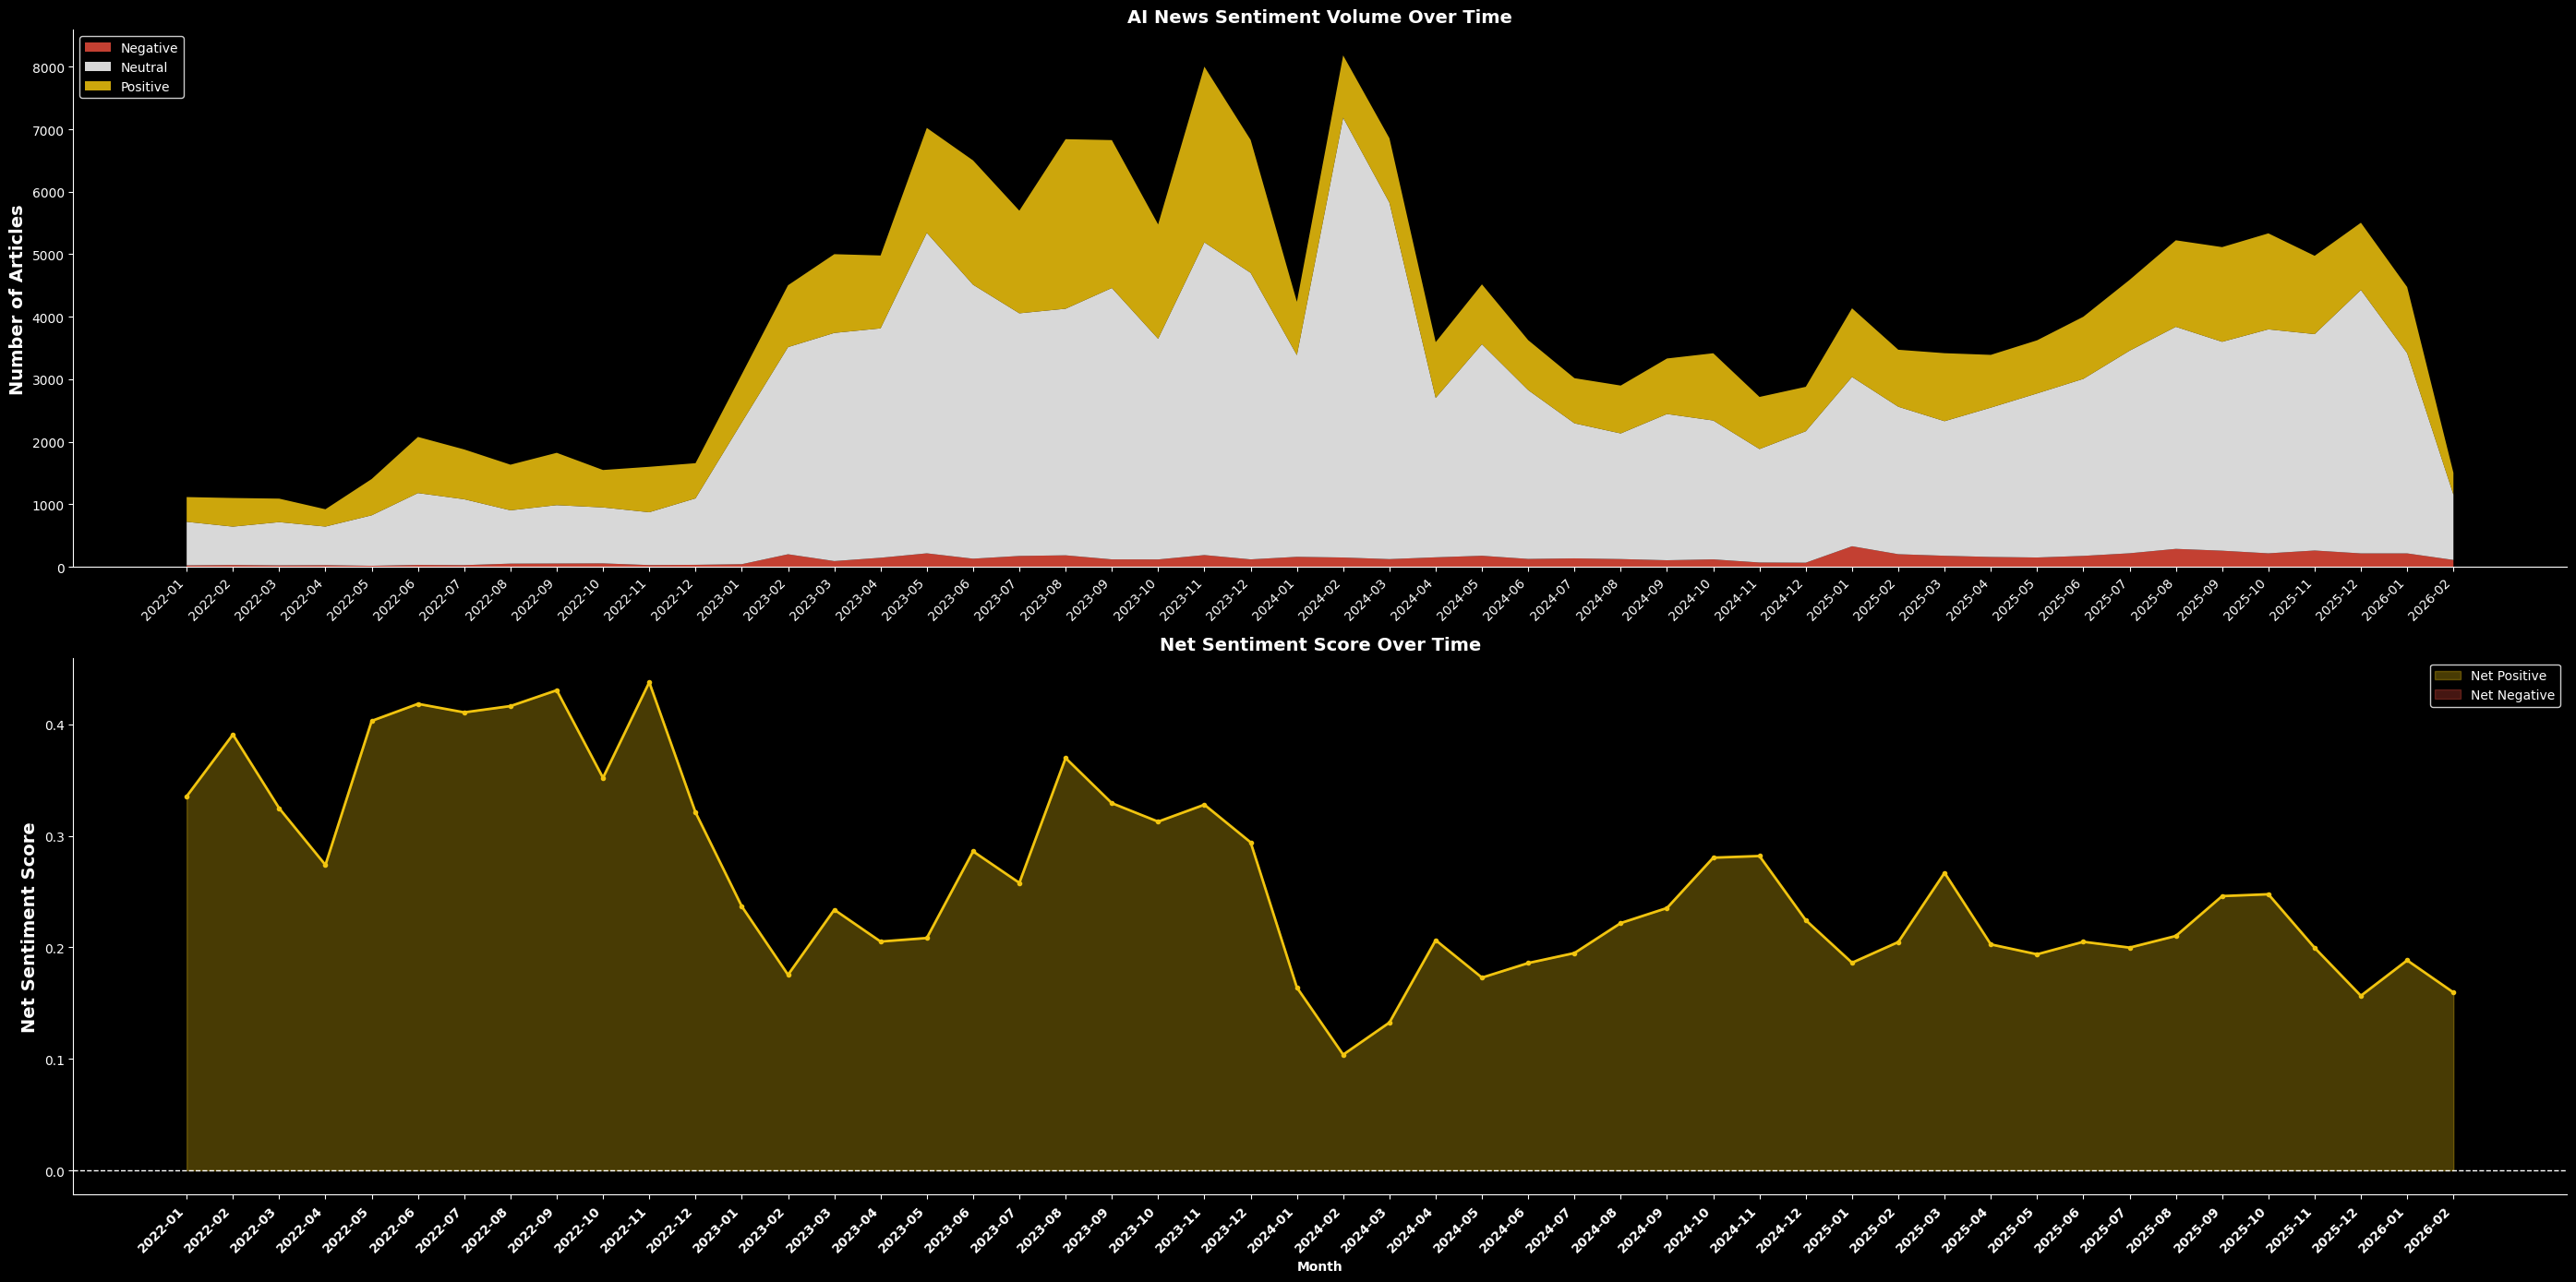

In [ ]:
time_sentiment = (
    df_articles[df_articles['sentiment_label'].notna()]
    .groupby(['year_month', 'sentiment_label'])['article_id']
    .nunique()
    .reset_index()
    .rename(columns={'article_id': 'count'})
)

time_pivot = time_sentiment.pivot_table(
    index='year_month',
    columns='sentiment_label',
    values='count',
    fill_value=0
).reset_index()

for col in ['positive', 'neutral', 'negative']:
    if col not in time_pivot.columns:
        time_pivot[col] = 0

# net sentiment per month
time_pivot['net_sentiment'] = (
    (time_pivot['positive'] - time_pivot['negative']) /
    (time_pivot['positive'] + time_pivot['neutral'] + time_pivot['negative'])
)

time_pivot = time_pivot.sort_values('year_month')
time_pivot['year_month_str'] = time_pivot['year_month'].astype(str)

# volume over time
fig, axes = plt.subplots(2, 1, figsize=(28, 14))
fig.patch.set_facecolor('black')


axes[0].stackplot(
    time_pivot['year_month_str'],
    time_pivot['negative'],
    time_pivot['neutral'],
    time_pivot['positive'],
    labels=['Negative', 'Neutral', 'Positive'],
    colors=[COLORS['negative'], COLORS['neutral'], COLORS['positive']],
    alpha=0.85
)
axes[0].set_title('AI News Sentiment Volume Over Time',
                  fontsize=14, fontweight='bold', color='white')
axes[0].set_ylabel('Number of Articles', color='white', fontweight = 'bold', fontsize = 14)
axes[0].set_facecolor('black')
axes[0].tick_params(colors='white')
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].spines[['bottom', 'left']].set_color('white')
axes[0].legend(facecolor='black', labelcolor='white',
               edgecolor='white', loc='upper left')
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right', color='white')

axes[1].plot(
    time_pivot['year_month_str'],
    time_pivot['net_sentiment'],
    color=COLORS['positive'],
    linewidth=2,
    marker='o',
    markersize=3
)
axes[1].fill_between(
    time_pivot['year_month_str'],
    time_pivot['net_sentiment'],
    0,
    where=time_pivot['net_sentiment'] >= 0,
    color=COLORS['positive'],
    alpha=0.3,
    label='Net Positive'
)
axes[1].fill_between(
    time_pivot['year_month_str'],
    time_pivot['net_sentiment'],
    0,
    where=time_pivot['net_sentiment'] < 0,
    color=COLORS['negative'],
    alpha=0.3,
    label='Net Negative'
)
axes[1].axhline(y=0, color='white', linewidth=1, linestyle='--')
axes[1].set_title('Net Sentiment Score Over Time',
                  fontsize=14, fontweight='bold', color='white')
axes[1].set_ylabel('Net Sentiment Score', color='white', fontweight = 'bold', fontsize = 14)
axes[1].set_xlabel('Month', color='white',fontweight='bold')
axes[1].set_facecolor('black')
axes[1].tick_params(colors='white')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].spines[['bottom', 'left']].set_color('white')
axes[1].legend(facecolor='black', labelcolor='white', edgecolor='white')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right', color='white',fontweight='bold')

plt.tight_layout()
plt.savefig(path + 'figures/sentiment_over_time.png',
            dpi=600, bbox_inches='tight', facecolor='black')
plt.show()

### ENTITY LEVEL

In [ ]:
# company level sentiment aggregation
filtered_df_entity = df_entity[
    (df_entity['industry'] != 'Unknown') &
    (df_entity['org'].str.lower().isin(lowercase_company_names))
]

company_sentiment_full = (
    filtered_df_entity
    .groupby(['org', 'industry'])
    .agg(
        total_mentions=('article_id', 'nunique'),
        net_sentiment=('sentiment_label', lambda x: net_sentiment(
            pd.DataFrame({'sentiment_label': x})
        )),
        pct_positive=('sentiment_label', lambda x: (x == 'positive').mean()),
        pct_neutral=('sentiment_label', lambda x: (x == 'neutral').mean()),
        pct_negative=('sentiment_label', lambda x: (x == 'negative').mean())
    )
    .reset_index()
)

MIN_MENTIONS = 10
company_sentiment_filtered = company_sentiment_full[
    company_sentiment_full['total_mentions'] >= MIN_MENTIONS
].copy()

print(f"Companies with {MIN_MENTIONS}+ mentions: {len(company_sentiment_filtered)}")
print(company_sentiment_filtered.sort_values(
    'net_sentiment', ascending=False).head(10).to_string())

Companies with 10+ mentions: 2852
                       org            industry  total_mentions  net_sentiment  pct_positive  pct_neutral  pct_negative
5105              Yokogawa       Manufacturing              16            1.0           1.0          0.0           0.0
5104              Yodaplus          Technology              13            1.0           1.0          0.0           0.0
5100                  Yext          Technology              12            1.0           1.0          0.0           0.0
5023              Wishpond          Technology              11            1.0           1.0          0.0           0.0
4972                  Weka          Technology              33            1.0           1.0          0.0           0.0
4963                Webapp          Technology              10            1.0           1.0          0.0           0.0
4914                Vsblty          Technology              36            1.0           1.0          0.0           0.0
4887          

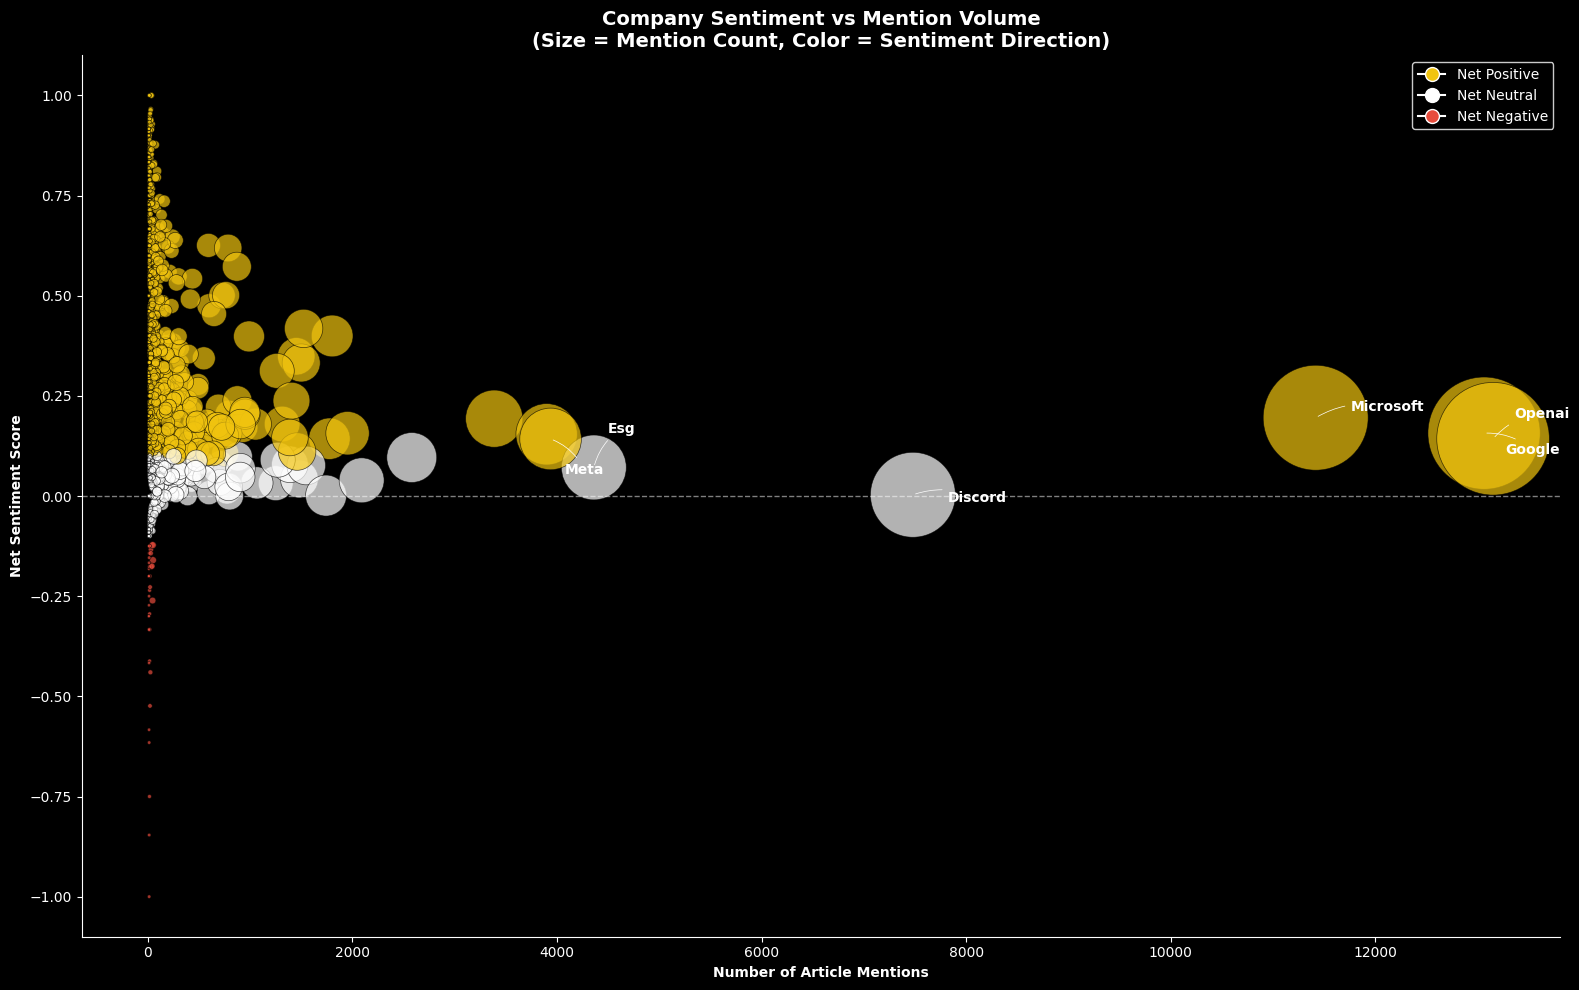

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

# company bubble chat
fig, ax = plt.subplots(figsize=(16, 10))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

bubble_colors = company_sentiment_filtered['net_sentiment'].apply(
    lambda x: COLORS['positive'] if x > 0.1
    else COLORS['negative'] if x < -0.1
    else COLORS['neutral']
)

scatter = ax.scatter(
    company_sentiment_filtered['total_mentions'],
    company_sentiment_filtered['net_sentiment'],
    s=company_sentiment_filtered['total_mentions'] * 0.5,
    c=bubble_colors,
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5
)

top_companies_to_annotate = company_sentiment_filtered.nlargest(6, 'total_mentions')

xytext_offsets = [(15, 15), (15, -15), (25, 5), (25, -5), (10, 25), (10, -25), (30, 0), (0, 30), (0, -30), (-15, 15)]

for i, (_, row) in enumerate(top_companies_to_annotate.iterrows()):
    offset = xytext_offsets[i % len(xytext_offsets)]
    ax.annotate(
        row['org'],
        (row['total_mentions'], row['net_sentiment']),
        fontsize=10,
        color='white',
        xytext=offset,
        textcoords='offset points',
        fontweight='bold',
        arrowprops=dict(arrowstyle='-', color='white', linewidth=0.5, connectionstyle='arc3,rad=0.2')
    )

ax.axhline(y=0, color='white', linewidth=1, linestyle='--', alpha=0.5)
ax.set_title('Company Sentiment vs Mention Volume\n'
             '(Size = Mention Count, Color = Sentiment Direction)',
             fontsize=14, fontweight='bold', color='white')
ax.set_xlabel('Number of Article Mentions', color='white',fontweight='bold')
ax.set_ylabel('Net Sentiment Score', color='white', fontweight='bold')
ax.tick_params(colors='white')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['bottom', 'left']].set_color('white')

legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=COLORS['positive'],
           markersize=10, label='Net Positive'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=COLORS['neutral'],
           markersize=10, label='Net Neutral'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=COLORS['negative'],
           markersize=10, label='Net Negative'),
]
ax.legend(handles=legend_elements, facecolor='black',
          labelcolor='white', edgecolor='white')

plt.tight_layout()
plt.savefig(path + 'figures/company_sentiment_bubble.png',
            dpi=600, bbox_inches='tight', facecolor='black')
plt.show()

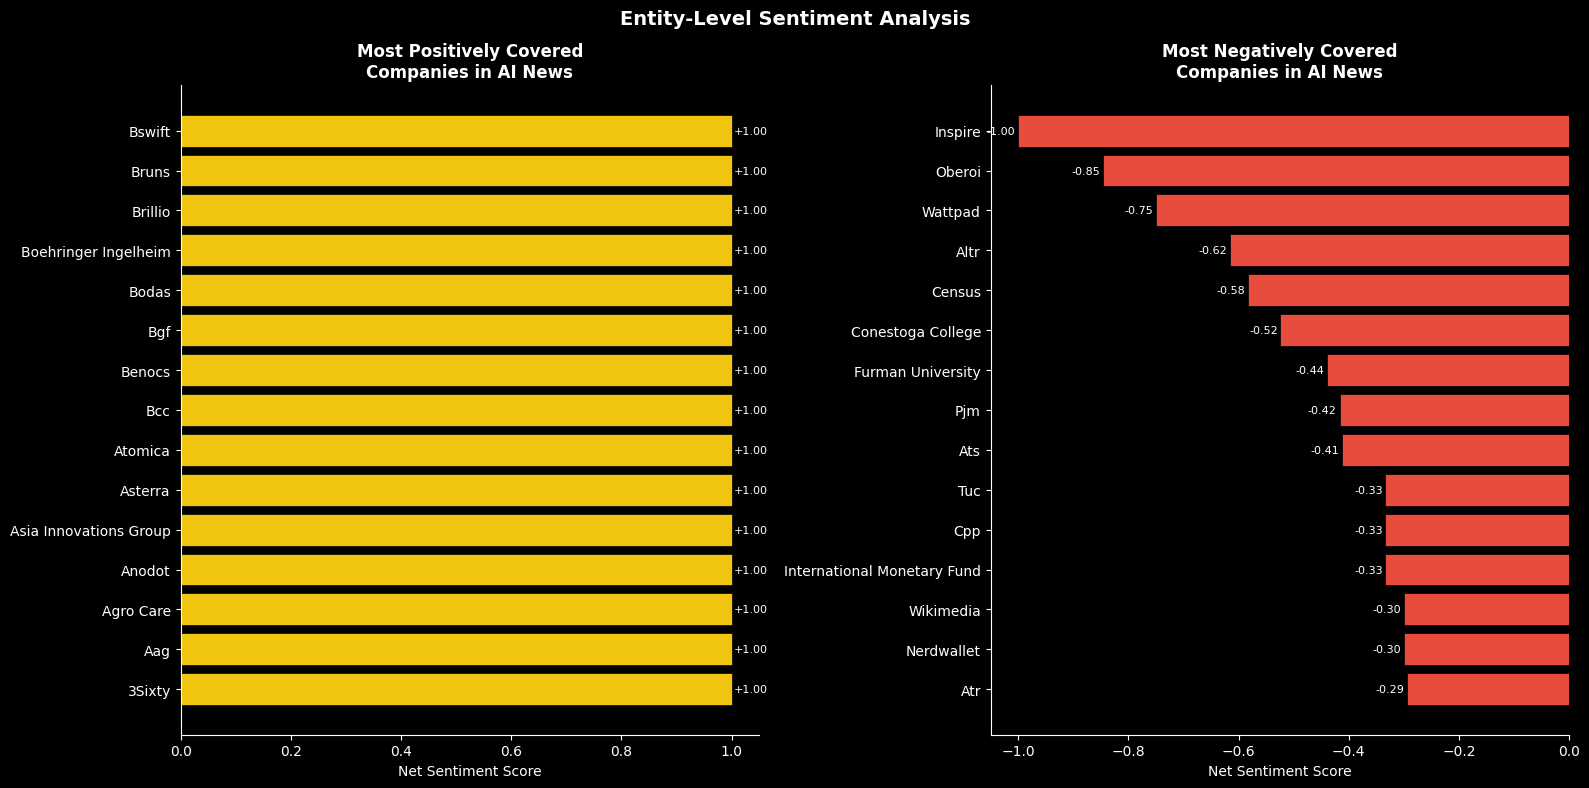

In [ ]:
# top positive and negative companies
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor('black')

#most positively covered
most_positive = (
    company_sentiment_filtered
    .nlargest(15, 'net_sentiment')
    .sort_values('net_sentiment')
)

axes[0].barh(
    most_positive['org'],
    most_positive['net_sentiment'],
    color=COLORS['positive'],
    edgecolor='black',
    linewidth=0.5
)
for i, (val, company) in enumerate(
        zip(most_positive['net_sentiment'], most_positive['org'])):
    axes[0].text(val + 0.005, i, f'{val:+.2f}',
                 va='center', fontsize=8, color='white')

axes[0].set_title('Most Positively Covered\nCompanies in AI News',
                  fontsize=12, fontweight='bold', color='white')
axes[0].set_xlabel('Net Sentiment Score', color='white')
axes[0].set_facecolor('black')
axes[0].tick_params(colors='white')
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].spines[['bottom', 'left']].set_color('white')
for label in axes[0].get_yticklabels():
    label.set_color('white')

# most negatively covered
most_negative = (
    company_sentiment_filtered
    .nsmallest(15, 'net_sentiment')
    .sort_values('net_sentiment', ascending=False)
)

axes[1].barh(
    most_negative['org'],
    most_negative['net_sentiment'],
    color=COLORS['negative'],
    edgecolor='black',
    linewidth=0.5
)
for i, (val, company) in enumerate(
        zip(most_negative['net_sentiment'], most_negative['org'])):
    axes[1].text(val - 0.005, i, f'{val:+.2f}',
                 va='center', ha='right', fontsize=8, color='white')

axes[1].set_title('Most Negatively Covered\nCompanies in AI News',
                  fontsize=12, fontweight='bold', color='white')
axes[1].set_xlabel('Net Sentiment Score', color='white')
axes[1].set_facecolor('black')
axes[1].tick_params(colors='white')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].spines[['bottom', 'left']].set_color('white')
for label in axes[1].get_yticklabels():
    label.set_color('white')

plt.suptitle('Entity-Level Sentiment Analysis',
             fontsize=14, fontweight='bold', color='white')
plt.tight_layout()
plt.savefig(path + 'figures/company_sentiment_top_bottom.png',
            dpi=300, bbox_inches='tight', facecolor='black')
plt.show()

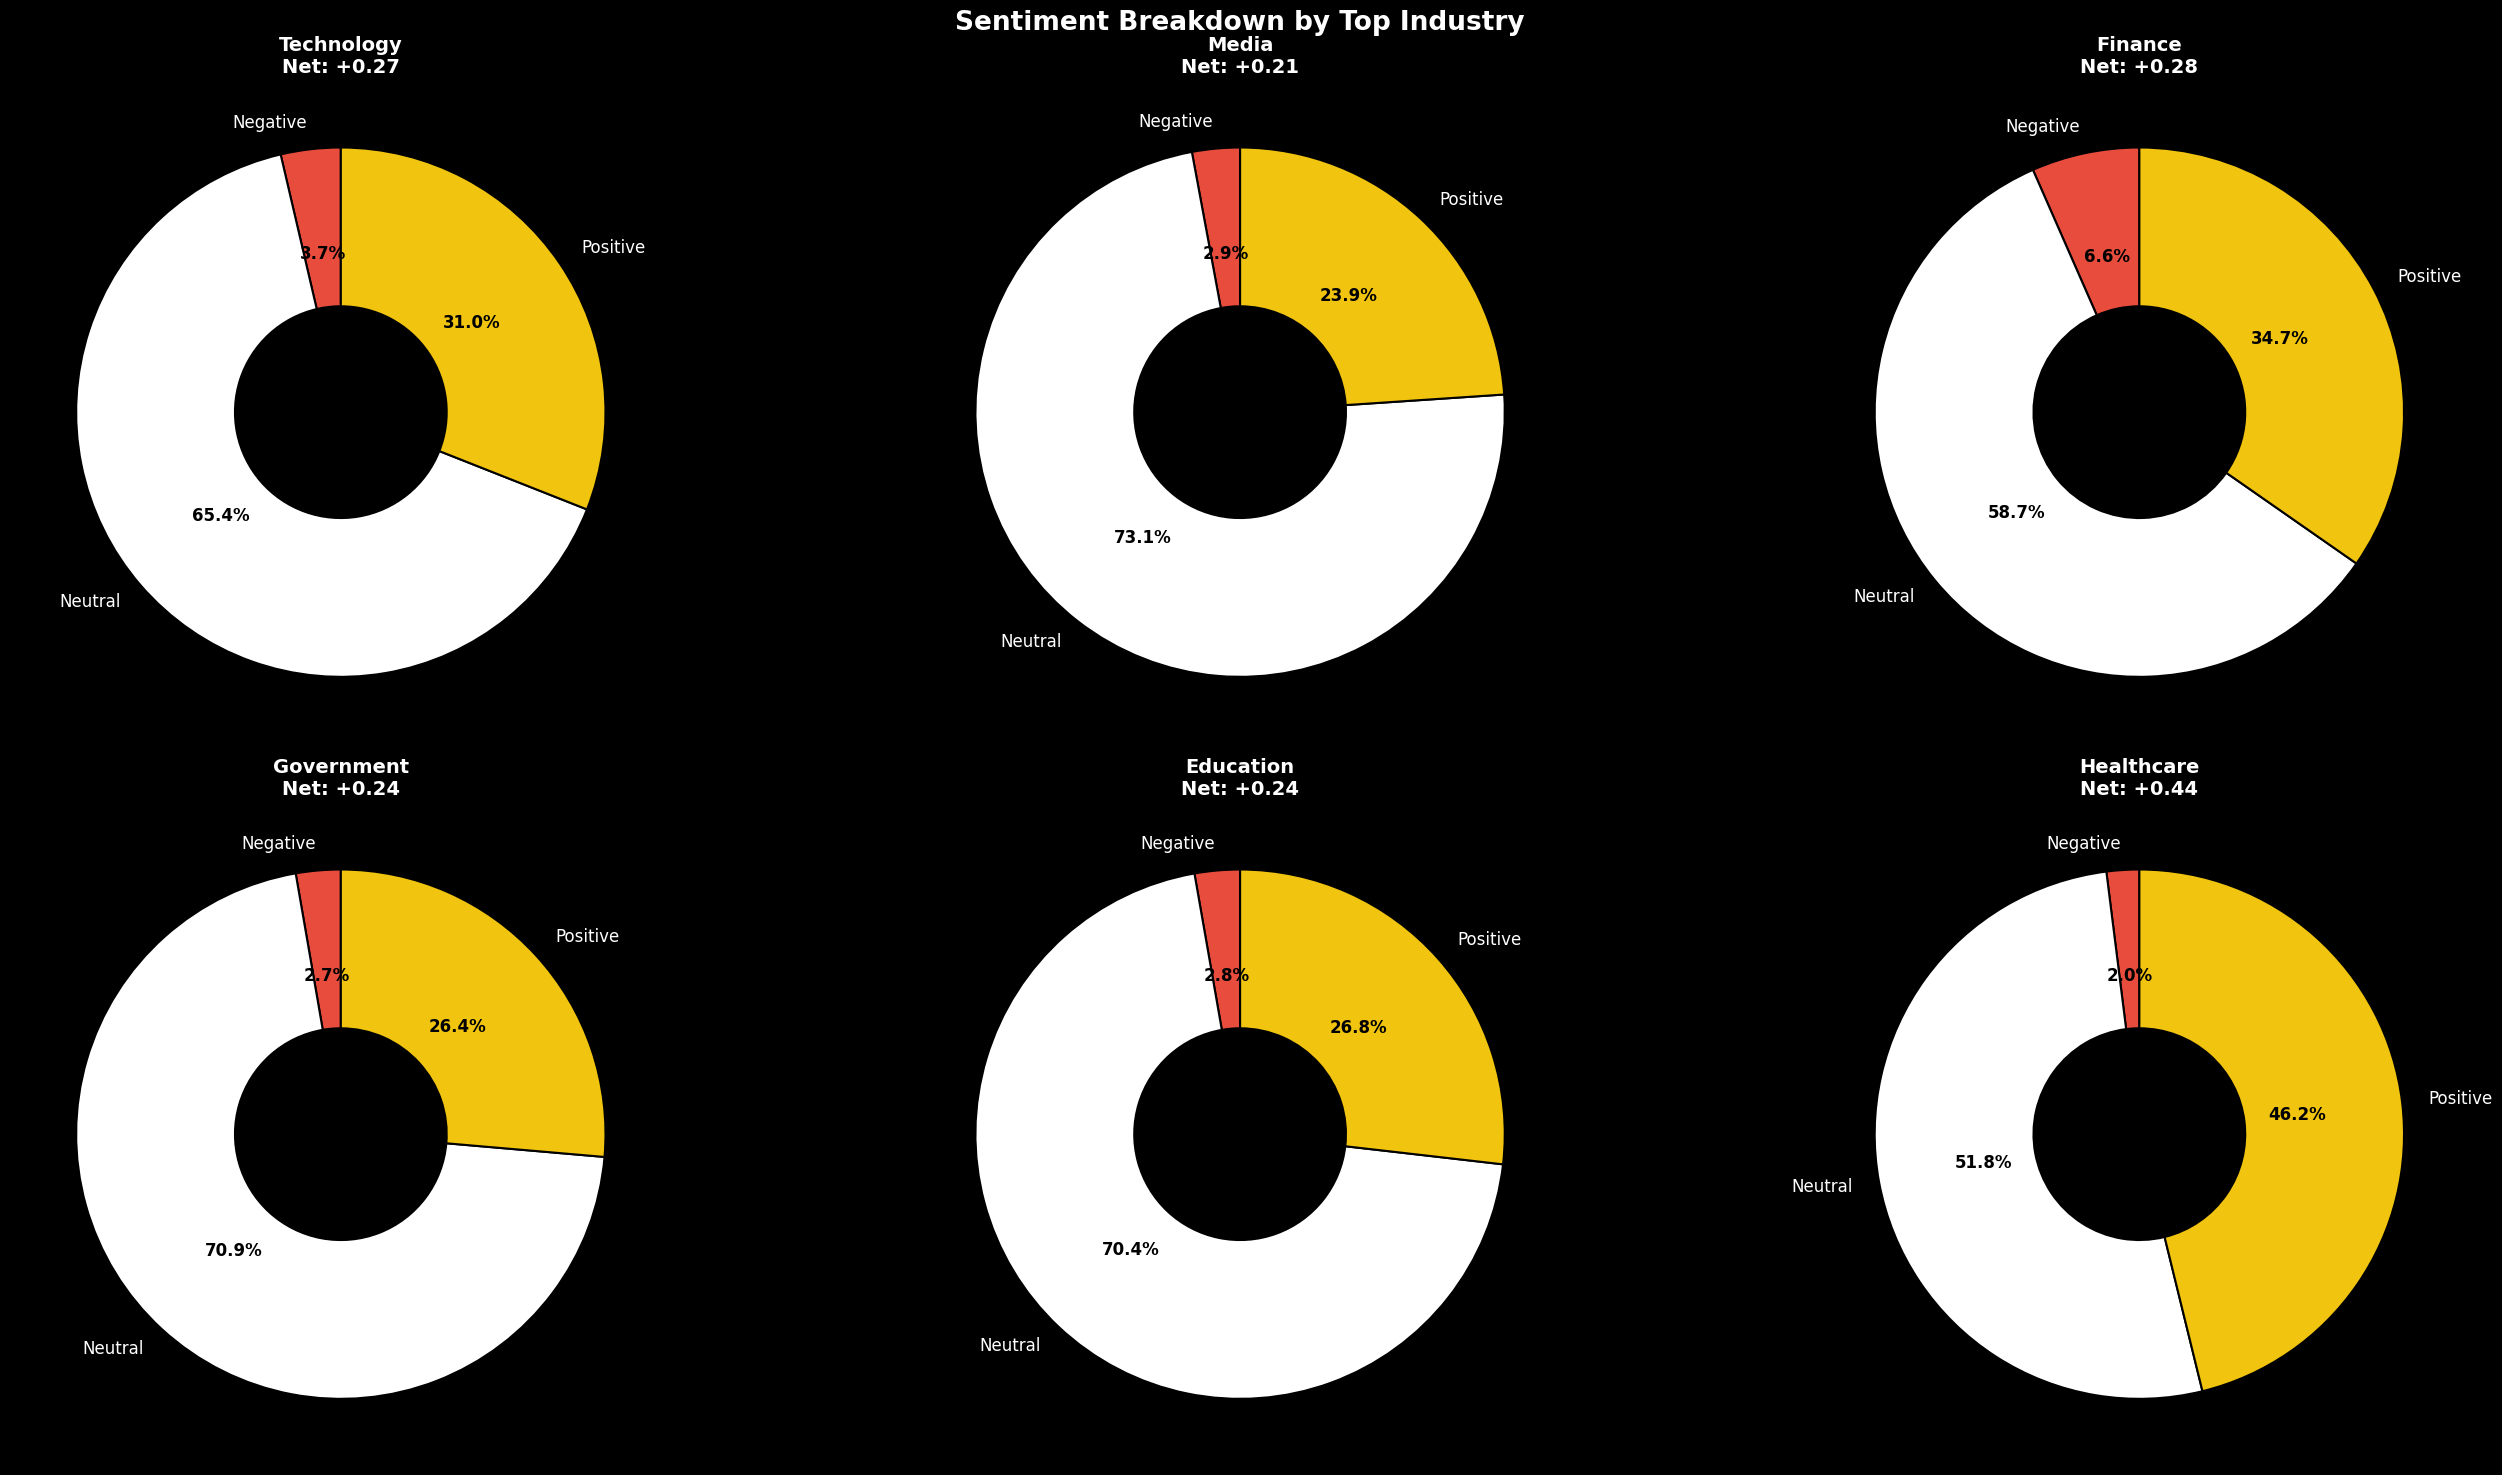

In [ ]:
# sentiment donut
top6_industries = industry_sentiment.nlargest(6, 'total_articles')['industry'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(28, 15))
fig.patch.set_facecolor('black')
axes = axes.flatten()

for ax, industry in zip(axes, top6_industries):
    ind_data = industry_sentiment[
        industry_sentiment['industry'] == industry
    ].iloc[0]

    sizes = [
        ind_data['pct_negative'],
        ind_data['pct_neutral'],
        ind_data['pct_positive']
    ]
    colors = [COLORS['negative'], COLORS['neutral'], COLORS['positive']]
    labels = ['Negative', 'Neutral', 'Positive']

    wedges, texts, autotexts = ax.pie(
        sizes,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'black', 'linewidth': 1.5,
                    'width': 0.6}
    )
    for text in texts:
        text.set_color('white')
        text.set_fontsize(12)
    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(12)

    ax.set_title(f'{industry}\nNet: {ind_data["net_sentiment"]:+.2f}',
                 fontsize=14, fontweight='bold', color='white')
    ax.set_facecolor('black')

plt.suptitle('Sentiment Breakdown by Top Industry',
             fontsize=19, fontweight='bold', color='white')
plt.tight_layout()
plt.savefig(path + 'figures/industry_sentiment_donuts.png',
            dpi=600, bbox_inches='tight', facecolor='black')
plt.show()

In [ ]:
top6_companies = top_companies_overall['org'].tolist()

top_companies_articles = df_entity[
    (df_entity['org'].isin(top6_companies)) &
    (~df_entity['is_noise_topic'])
].copy()

print(f"Shape of top_companies_articles: {top_companies_articles.shape}")
print("First 5 rows of top_companies_articles:")
print(top_companies_articles.head())

Shape of top_companies_articles: (35813, 13)
First 5 rows of top_companies_articles:
     article_id        org    industry sentiment_label  sentiment_score  \
64           14     Openai  Technology         neutral         0.894233   
82           18  Microsoft  Technology         neutral         0.979792   
192          44     Openai  Technology         neutral         0.703536   
193          44     Google  Technology         neutral         0.703536   
232          53     Google  Technology        positive         0.757996   

     prob_negative  prob_neutral  prob_positive  topic_id  \
64        0.004028      0.894233       0.101739         1   
82        0.003283      0.979792       0.016925         0   
192       0.005918      0.703536       0.290546         1   
193       0.005918      0.703536       0.290546         1   
232       0.004112      0.237892       0.757996         0   

                          topic_label  is_noise_topic       date year_month  
64   Global AI Mark

In [ ]:
company_topic_counts = (
    top_companies_articles.groupby(['org', 'topic_label'])['article_id']
    .nunique()
    .reset_index()
    .rename(columns={'article_id': 'article_count'})
)

# top topic for each company
top_topics_per_company = (
    company_topic_counts.loc[company_topic_counts.groupby('org')['article_count'].idxmax()]
    .sort_values('article_count', ascending=False)
)

print("Most frequent AI topic for each of the top 6 companies:")
print(top_topics_per_company.to_string())


Most frequent AI topic for each of the top 6 companies:
           org                            topic_label  article_count
3      Discord  AI Generated Image Asset Distribution           7291
22         Esg        AI in Consumer Media Technology           3740
136     Openai       Global AI Market Trends Analysis           3258
109  Microsoft       Global AI Market Trends Analysis           2673
54      Google       Global AI Market Trends Analysis           2339
80        Meta       Global AI Market Trends Analysis            975


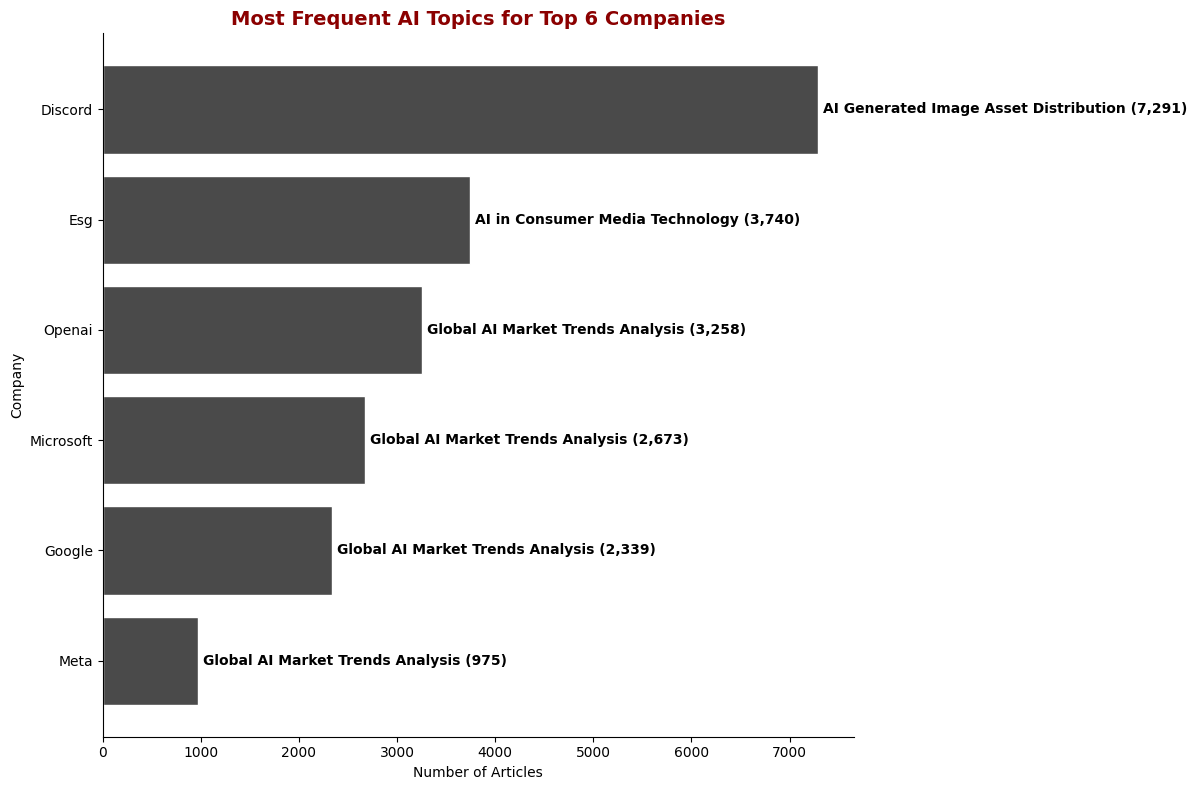

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    top_topics_per_company['org'],
    top_topics_per_company['article_count'],
    color='#4a4a4a',
    edgecolor='white'
)

for i, (org, topic, count) in enumerate(top_topics_per_company.itertuples(index=False)):
    ax.text(count + 50, i,
            f'{topic} ({count:,})',
            va='center', fontsize=10, color='black', fontweight='bold')

ax.set_title('Most Frequent AI Topics for Top 6 Companies', fontsize=14, fontweight='bold', color = '#8B0000')
ax.set_xlabel('Number of Articles', color='black')
ax.set_ylabel('Company', color='black')
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(path + 'figures/top_companies_dominant_topics.png', dpi=600, bbox_inches='tight')
plt.show()